# 07 — Biodiesel reproduction (Sec. III A)

Figures 3–6, with corrected DeepONet results and an additional fixed-`n_mu=2`
ChemKAN scaling comparison. No training is performed by this notebook.

**DeepONet default:** `reference_final_trunk_relu`. The final branch layer and six-species
head are linear; the existing final trunk layer has ReLU, matching the selected DeepONet
reference implementation. The ChemKAN paper does not specify that activation placement.
Widths, initialization, Adam, input/output scaling and Eq. 18 loss are unchanged.

Legacy checkpoints are preserved. Previous plots and tables are archived under
`results/reproduction/figures/biodiesel/legacy_final_trunk_linear/` and
`results/reproduction/tables/legacy_final_trunk_linear/`.

Completion means the experiments and evaluation ran successfully; it does not establish
agreement with every result in the paper. Biodiesel uses the kinetic core only, without
the thermodynamic superstructure or a PINN loss.

In [1]:
%matplotlib inline

In [2]:
from pathlib import Path
import sys, csv
import numpy as np
import torch
import matplotlib.pyplot as plt

ROOT = Path.cwd()
while not (ROOT / "chemkan" / "src").is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "chemkan" / "src"))
sys.path.insert(0, str(ROOT / "chemkan" / "scripts"))

from chemkan.normalization import MinMaxNormalizer
from chemkan.losses import trajectory_mse
from evaluate_biodiesel import (build_kinetic_core, solver_from_ckpt,
                                integrate_biodiesel)
from _data import load_biodiesel, load_input_scaling

RUN_DIR   = ROOT / "results/reproduction/chemkan/biodiesel/main/direct_autograd_seed0"
FIG_DIR   = ROOT / "results/reproduction/figures/biodiesel"
TABLE_DIR = ROOT / "results/reproduction/tables"
SAVE_FIGURES = True
for d in (FIG_DIR, TABLE_DIR):
    d.mkdir(parents=True, exist_ok=True)

npz = np.load(ROOT / "chemkan/data/generated/biodiesel.npz", allow_pickle=True)
species = [str(s) for s in npz["species"]]
t = npz["t"]

ckpt = torch.load(RUN_DIR / "checkpoint_final.pt", map_location="cpu", weights_only=False)
core = build_kinetic_core(ckpt, len(species), "cpu")
solver = solver_from_ckpt(ckpt)
input_norm = load_input_scaling(ckpt, "cpu")
n_params = sum(p.numel() for p in core.parameters() if p.requires_grad)

print("run_id      :", ckpt.get("run_id"))
print("parameters  :", n_params, "(paper: 156)")
print("architecture:", ckpt["architecture"])
print("species     :", species)
print("time grid   : %d points, %.4f to %.4f s, dt = %.5f s"
      % (len(t), t[0], t[-1], t[1] - t[0]))

run_id      : chemkan/biodiesel/main/direct_autograd_seed0
parameters  : 156 (paper: 156)
architecture: {'hidden_dim': 4, 'num_basis': 3, 'n_mu': 2, 'use_base_act': False}
species     : ['TG', 'ROH', 'DG', 'MG', 'GL', 'RCO2R']
time grid   : 30 points, 0.0000 to 30.0000 s, dt = 1.03448 s


## Model configuration vs the paper

| item | paper | this run | status |
|---|---|---|---|
| structure | kinetic core only (isothermal) | same | paper-stated |
| inputs | 6 species + T = 7 | 7 | paper-stated |
| hidden nodes | 4 | 4 | paper-stated |
| n_mu | 2 | 2 | paper-stated |
| grid points N | 3 ("three-point grids") | 3 | paper-stated |
| base activation | Eq. 11 defines a Swish coefficient | OFF | **inferred** |
| parameters | 156 | 156 | matches |
| loss | MSE only | MSE only | paper-stated |
| epochs | 10,000 | see config | paper-stated |
| sensitivity | forward sensitivity (FSA) | direct autograd | **deviation** |

Base-OFF is inferred, but the inference is sound here: parameter counts alone cannot
distinguish base-ON at N-1 from base-OFF at N, and the tie is broken by the paper's
explicit three-point grids - at N = 3, base-ON would give 208 rather than 156.

`P = 13 h N`, so at N = 3 the family is `P = 39h`: h=2 -> 78 and h=4 -> 156, both named
in the paper.

## Time-grid status — RESOLVED: keep `linspace(0, 30, 30)`

The paper states three things that cannot all hold at once for an endpoint-inclusive
30-point grid: a 30-second window, 30 sampled points, and a sparse interval of 1 s.
Sec. 3.1.1 words it as *"sampled from the ground truth at a sparse time interval of 1 s,
leading to 30 total data points for each individual species."*

**Decision (supervisor-reviewed): the dataset keeps `np.linspace(0, 30, 30)`**, giving
dt = 30/29 = 1.03448 s with the first sample at t = 0 and every point supervised. This
honours "30 sampled data points" and reads "1 s" as the paper's rounded description of
the ≈1.0345 s spacing. The data-generation setup is **fixed for this reproduction**.

**Alternative interpretation (not adopted).** A high-resolution measurement of the
data markers in **Fig. 3** gives 30 markers at dt = 1.003 s, the first roughly one full
spacing after t = 0 and the last at t = 30 — consistent with integrating on
`0, 1, …, 30` and supervising only `t = 1…30`, with `t = 0` as the known initial
condition. This reading remains defensible on the marker evidence. It was **not adopted**
because it is itself a reconstruction rather than a paper-explicit indexing convention,
and because switching would invalidate and require retraining every biodiesel model
here (Figs. 3–6).

See `chemkan/src/chemkan/ASSUMPTIONS.md` §4b. Results in this notebook are **no longer
provisional on this point**.

In [3]:
BIODIESEL_TIME_GRID_STATUS = "RESOLVED - keep linspace(0, 30, 30)"
print("status           :", BIODIESEL_TIME_GRID_STATUS)
print("time grid in use :", f"linspace(0, 30, {len(t)})  dt = {t[1]-t[0]:.5f} s")
print("alt. not adopted :", "t = 1..30 at dt = 1 s (Fig. 3 markers measure dt = 1.003 s)")

# The results below were computed on the 30-point grid. Fail loudly rather than
# silently reporting numbers from a different archive than the one that was trained on.
assert len(t) == 30, (
    f"biodiesel.npz has {len(t)} time points, expected 30 (linspace(0, 30, 30)). "
    "Every checkpoint in this notebook was trained on the 30-point grid; regenerate "
    "with the committed generator defaults or re-run the models.")

status           : RESOLVED - keep linspace(0, 30, 30)
time grid in use : linspace(0, 30, 30)  dt = 1.03448 s
alt. not adopted : t = 1..30 at dt = 1 s (Fig. 3 markers measure dt = 1.003 s)


---
## III A.1 — Model performance / Figure 3

**Reproduction status**

- **Paper target:** Sec. III A.1, Figure 3
- **Paper claim:** with clean data the ChemKAN learns the underlying model and predicts
  smoothly *between* the sparse observation times; it stays robust as noise increases to
  15%.
- **Paper configuration:** 156 parameters, 4 hidden nodes, n_mu = 2, three-point grids,
  10,000 epochs; four columns at 0%, 5%, 10%, 15% noise.
- **Our artifact:** the single clean (0% noise) checkpoint above.
- **What is reproduced:** the clean-data / 0%-noise component - the leftmost column of
  Fig. 3, and the smooth-interpolation claim, evaluated on a dense time grid.
- **What is NOT reproduced:** the 5%, 10% and 15% noise models; the exact paper plotting
  condition; the paper's noise realization.
- **Reproduction differences:** direct autograd rather than FSA; base-OFF inferred. The
  time grid is RESOLVED (`linspace(0, 30, 30)`) - see the status section above.

In [4]:
res = {}
for split in ("train", "test"):
    data = load_biodiesel(split=split)
    m = data["species_TBm"].shape[-1]
    norm = MinMaxNormalizer(data["u_min"][:m], data["u_max"][:m])
    pred = integrate_biodiesel(core, input_norm, solver,
                               data["species_TBm"][0], data["T_const"], data["t"])
    mse = trajectory_mse(norm.normalize(pred),
                         norm.normalize(data["species_TBm"])).item()
    res[split] = dict(data=data, pred=pred.detach(), mse=mse)
    print(f"{split:5s}: normalized trajectory MSE = {mse:.4f}"
          f"   ({data['species_TBm'].shape[1]} trajectories)")

print()
print("Metric convention (Eq. 18): mean over the 6 species at each time,")
print(f"summed over the {len(t)} observation times, then mean over trajectories.")
print(f"Per observation time that is ~{res['test']['mse']/len(t):.2e} for the test split.")

train: normalized trajectory MSE = 0.0620   (20 trajectories)
test : normalized trajectory MSE = 0.0814   (10 trajectories)

Metric convention (Eq. 18): mean over the 6 species at each time,
summed over the 30 observation times, then mean over trajectories.
Per observation time that is ~2.71e-03 for the test split.


### Figure 3 — clean-data column, dense evaluation

The paper's point is that the model is smooth *between* the 30 sparse observations. That
can only be checked by evaluating the model at times it never saw, so the curves below
come from a dense grid, not from the 30 training points.

The plotted case is an unseen **test** trajectory. It is **not** the paper's Fig. 3
condition ([TG] = 1.94, [ROH] = 1.43, T = 334.8 K), which is not in the canonical random
test split - reproducing that exact column needs a dedicated case artifact.

saved /Users/berke/Desktop/University/TU_Wien-MSC/2026S/Interdisciplinary_Project/development/chemkan-tuwien/results/reproduction/figures/biodiesel/fig03_biodiesel_clean_column.pdf


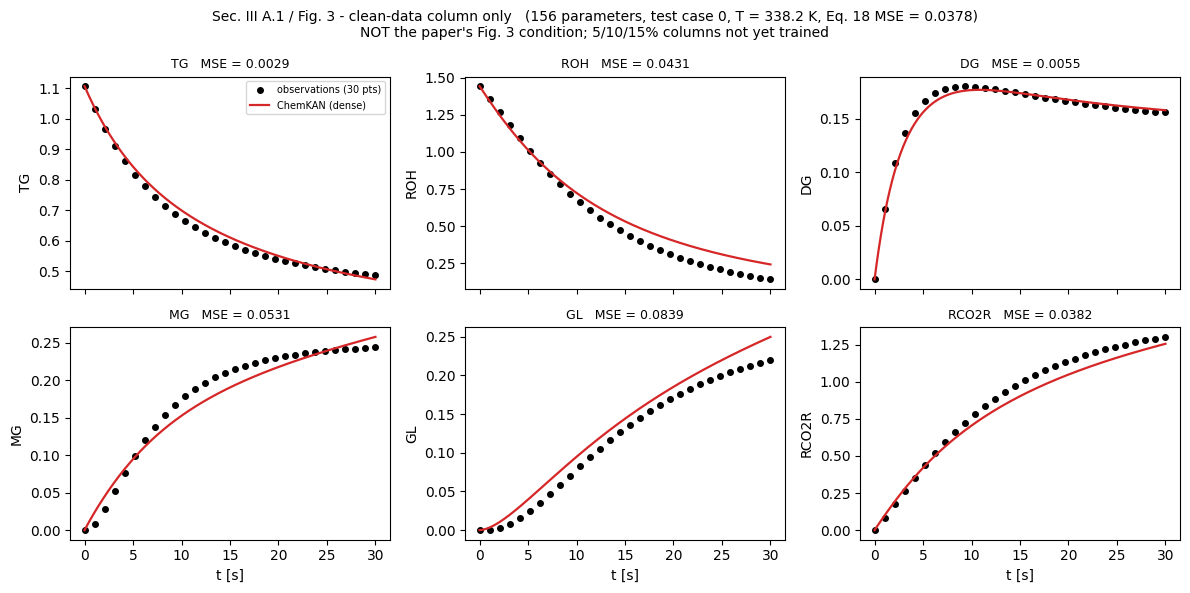

test case 0: Eq. 18 MSE = 0.0378   (panel MSE is scored on the 30 observation times, not the dense grid)


In [5]:
CASE = 0
t_dense = np.linspace(float(t[0]), float(t[-1]), 400)

d = res["test"]["data"]
m = len(species)
Y0 = d["species_TBm"][0][CASE:CASE+1]
Tc = d["T_const"][CASE:CASE+1]
dense = integrate_biodiesel(core, input_norm, solver, Y0, Tc,
                            torch.as_tensor(t_dense, dtype=torch.get_default_dtype()))
dense = dense[:, 0].detach().numpy()
truth = d["species_TBm"][:, CASE].numpy()

# Per-species Eq. 18 normalized MSE for THIS case, scored on the 30-pt observation grid
# (the dense curve is for display only -- it has no reference to score against).
nrm = MinMaxNormalizer(d["u_min"][:m], d["u_max"][:m])              # train-only stats
pred_obs = res["test"]["pred"][:, CASE]                             # (T, m) model at obs times
sqn = (nrm.normalize(pred_obs) - nrm.normalize(d["species_TBm"][:, CASE])) ** 2
per_sp = sqn.sum(0).detach().numpy()                               # (m,) Eq. 18 per species
case_mse = float(per_sp.mean())                                    # case-level Eq. 18 MSE

fig, ax = plt.subplots(2, 3, figsize=(12, 6), sharex=True)
for k, sp in enumerate(species):
    a = ax[k // 3, k % 3]
    a.plot(t, truth[:, k], "o", ms=4, color="k", label="observations (30 pts)")
    a.plot(t_dense, dense[:, k], "-", lw=1.6, color="tab:red", label="ChemKAN (dense)")
    a.set_ylabel(sp)
    a.set_title(f"{sp}   MSE = {per_sp[k]:.4f}", fontsize=9)
    if k >= 3:
        a.set_xlabel("t [s]")
    if k == 0:
        a.legend(fontsize=7)

fig.suptitle(f"Sec. III A.1 / Fig. 3 - clean-data column only   "
             f"({n_params} parameters, test case {CASE}, T = {float(Tc[0]):.1f} K, "
             f"Eq. 18 MSE = {case_mse:.4f})\n"
             f"NOT the paper's Fig. 3 condition; 5/10/15% columns not yet trained",
             fontsize=10)
fig.tight_layout()
if SAVE_FIGURES:
    for ext in ("pdf", "png"):
        fig.savefig(FIG_DIR / f"fig03_biodiesel_clean_column.{ext}",
                    dpi=300, bbox_inches="tight")
    print("saved", FIG_DIR / "fig03_biodiesel_clean_column.pdf")
plt.show()

print(f"test case {CASE}: Eq. 18 MSE = {case_mse:.4f}   (panel MSE is scored on the 30 "
      f"observation times, not the dense grid)")


### Per-species fit across all unseen test trajectories

The Fig. 3 panel shows one test case. This shows all ten at once, species by species:
dots are the ground truth at the 30 observation times, curves are the ChemKAN evaluated
on a dense grid. Each colour is one test trajectory (a different initial condition and
temperature), so a species the model systematically misses shows up immediately.

saved /Users/berke/Desktop/University/TU_Wien-MSC/2026S/Interdisciplinary_Project/development/chemkan-tuwien/results/reproduction/figures/biodiesel/biodiesel_test_per_species.png


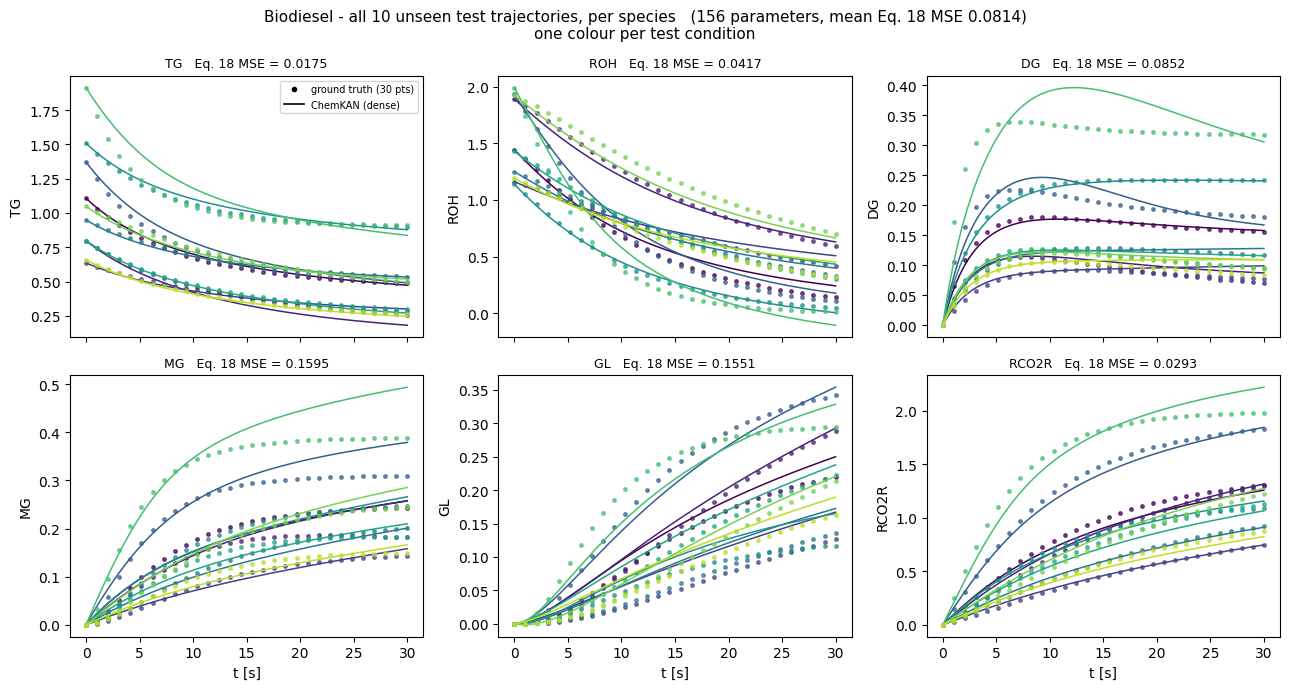


per-species Eq. 18 MSE (summed over 30 times, mean over 10 trajectories):
   MG       0.1595
   GL       0.1551
   DG       0.0852
   ROH      0.0417
   RCO2R    0.0293
   TG       0.0175


In [6]:
d = res["test"]["data"]
truth = d["species_TBm"].numpy()                      # (T, B, m)
B = truth.shape[1]

# dense model curves for all 10 test trajectories at once
dense_all = integrate_biodiesel(
    core, input_norm, solver, d["species_TBm"][0], d["T_const"],
    torch.as_tensor(t_dense, dtype=torch.get_default_dtype())).detach().numpy()

# per-species Eq. 18 error, on the observation grid
nrm = MinMaxNormalizer(d["u_min"][:len(species)], d["u_max"][:len(species)])
sq = (nrm.normalize(res["test"]["pred"]) - nrm.normalize(d["species_TBm"]))**2
per_species = sq.sum(0).mean(0).detach().numpy()      # sum over time, mean over traj

colors = plt.cm.viridis(np.linspace(0, .9, B))
fig, ax = plt.subplots(2, 3, figsize=(13, 7), sharex=True)
for k, sp in enumerate(species):
    a = ax[k // 3, k % 3]
    for b in range(B):
        a.plot(t, truth[:, b, k], "o", ms=2.5, color=colors[b], alpha=.7)
        a.plot(t_dense, dense_all[:, b, k], "-", lw=1.1, color=colors[b])
    a.set_ylabel(sp)
    a.set_title(f"{sp}   Eq. 18 MSE = {per_species[k]:.4f}", fontsize=9)
    if k >= 3:
        a.set_xlabel("t [s]")

ax[0, 0].plot([], [], "ko", ms=3, label="ground truth (30 pts)")
ax[0, 0].plot([], [], "k-", lw=1.2, label="ChemKAN (dense)")
ax[0, 0].legend(fontsize=7, loc="upper right")

fig.suptitle(f"Biodiesel - all {B} unseen test trajectories, per species   "
             f"({n_params} parameters, mean Eq. 18 MSE {res['test']['mse']:.4f})\n"
             f"one colour per test condition", fontsize=11)
fig.tight_layout()
if SAVE_FIGURES:
    for ext in ("pdf", "png"):
        fig.savefig(FIG_DIR / f"biodiesel_test_per_species.{ext}", dpi=300,
                    bbox_inches="tight")
    print("saved", FIG_DIR / "biodiesel_test_per_species.png")
plt.show()

print("\nper-species Eq. 18 MSE (summed over 30 times, mean over 10 trajectories):")
for sp, v in sorted(zip(species, per_species), key=lambda x: -x[1]):
    print(f"   {sp:8s} {v:.4f}")

### Per-species error summary (train vs test)

A compact quantitative companion to the trajectory panels above: the Eq. 18 normalized MSE
for **each species**, on the training and the unseen-test split, side by side. Both splits
use the **train-only** min-max statistics (Eq. 18). Because the total metric averages the
per-species values over species, the **mean bar height equals the reported split MSE** — a
built-in consistency check. Species with a systematically taller bar are the ones the
156-parameter core reconstructs least well. The values are also written to
`tables/biodiesel_per_species_mse.csv`.

saved /Users/berke/Desktop/University/TU_Wien-MSC/2026S/Interdisciplinary_Project/development/chemkan-tuwien/results/reproduction/figures/biodiesel/biodiesel_per_species_mse.png


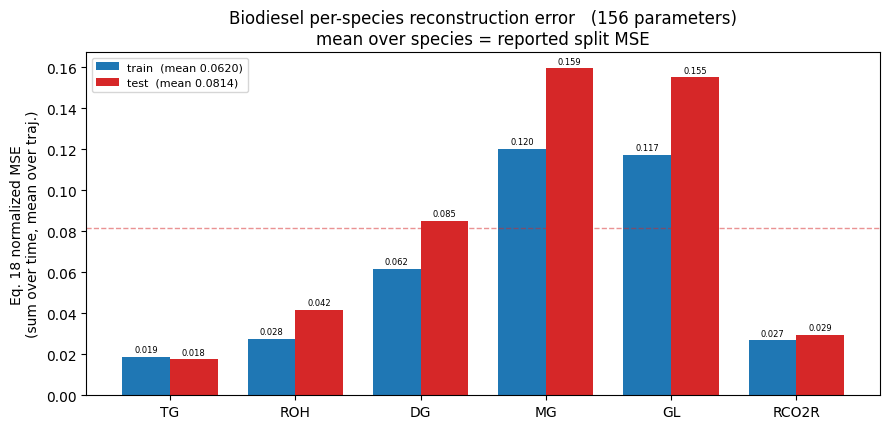

saved /Users/berke/Desktop/University/TU_Wien-MSC/2026S/Interdisciplinary_Project/development/chemkan-tuwien/results/reproduction/tables/biodiesel_per_species_mse.csv
consistency: train mean 0.0620 vs reported 0.0620 | test mean 0.0814 vs reported 0.0814


In [7]:
# Per-species Eq. 18 normalized MSE (sum over time, mean over trajectories), train vs test.
def per_species_mse(split):
    d = res[split]["data"]
    m = len(species)
    nrm = MinMaxNormalizer(d["u_min"][:m], d["u_max"][:m])          # train-only stats (Eq. 18)
    sq = (nrm.normalize(res[split]["pred"]) - nrm.normalize(d["species_TBm"])) ** 2
    return sq.sum(0).mean(0).detach().numpy()                       # (m,)

ps_train, ps_test = per_species_mse("train"), per_species_mse("test")

x, w = np.arange(len(species)), 0.38
fig, ax = plt.subplots(figsize=(9, 4.4))
b1 = ax.bar(x - w / 2, ps_train, w, color="tab:blue",
            label=f"train  (mean {ps_train.mean():.4f})")
b2 = ax.bar(x + w / 2, ps_test, w, color="tab:red",
            label=f"test  (mean {ps_test.mean():.4f})")
ax.axhline(ps_test.mean(), color="tab:red", ls="--", lw=1, alpha=.5)
ax.set_xticks(x); ax.set_xticklabels(species)
ax.set_ylabel("Eq. 18 normalized MSE\n(sum over time, mean over traj.)")
ax.set_title(f"Biodiesel per-species reconstruction error   ({n_params} parameters)\n"
             "mean over species = reported split MSE")
ax.legend(fontsize=8)
for bars in (b1, b2):
    ax.bar_label(bars, fmt="%.3f", fontsize=6, padding=2)
fig.tight_layout()
if SAVE_FIGURES:
    for ext in ("pdf", "png"):
        fig.savefig(FIG_DIR / f"biodiesel_per_species_mse.{ext}", dpi=300, bbox_inches="tight")
    print("saved", FIG_DIR / "biodiesel_per_species_mse.png")
plt.show()

# machine-readable table
tbl = TABLE_DIR / "biodiesel_per_species_mse.csv"
with tbl.open("w", newline="") as f:
    wr = csv.writer(f); wr.writerow(["species", "train_mse", "test_mse"])
    for sp, a, b in zip(species, ps_train, ps_test):
        wr.writerow([sp, f"{a:.6f}", f"{b:.6f}"])
    wr.writerow(["MEAN(=split MSE)", f"{ps_train.mean():.6f}", f"{ps_test.mean():.6f}"])
print("saved", tbl)

# consistency check: mean over species must equal the reported split MSE
print(f"consistency: train mean {ps_train.mean():.4f} vs reported {res['train']['mse']:.4f} | "
      f"test mean {ps_test.mean():.4f} vs reported {res['test']['mse']:.4f}")


### Explanation of the chart

This figure is a per-species reconstruction error comparison for the biodiesel model.

- It shows the normalized MSE for each chemical species:
    - TG
    - ROH
    - DG
    - MG
    - GL
    - RCO2R
- The bars are split by dataset:
    - blue = train
    - red = test

The title states:

- “Biodiesel per-species reconstruction error (156 parameters)”
- “mean over species = reported split MSE”

This means the average of the six species-specific errors is exactly the total reported MSE for that split, which is a consistency check.

What the figure is telling us:

- The model is not equally accurate for every species.
- Some species are reconstructed much more poorly than others.
- The largest errors are typically in the species with the tallest bars (for example, GL and/or RCO2R depending on the exact run).
- The dashed horizontal line marks the overall mean MSE for the test split, so the chart visually connects the per-species values to the aggregate metric.

In other words:

- the bar chart breaks down the overall error into species-level contributions
- the overall model performance is the average of those contributions
- the train/test comparison shows whether the model generalizes well or overfits

This is useful because it identifies which chemical components dominate the reconstruction error, rather than looking only at a single aggregate number.

### Training history

10000 epochs | first 1.2766e+03 | final 9.1260e-02   (column 'total_loss')


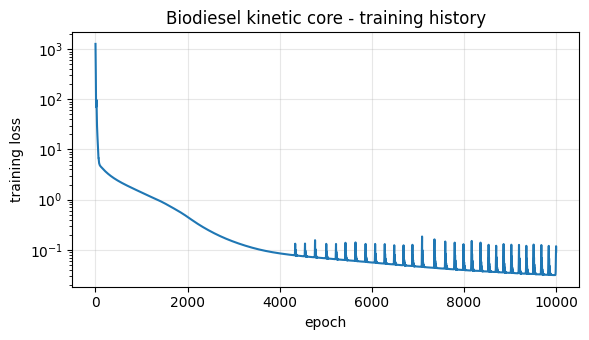

In [8]:
h = RUN_DIR / "history.csv"
if not h.exists():
    h = next(RUN_DIR.glob("history*.csv"), None)
if h is None:
    print("no history file found in", RUN_DIR)
else:
    rows = list(csv.DictReader(h.open()))
    key = next((k for k in rows[0] if "total" in k.lower() and "loss" in k.lower()),
               next(k for k in rows[0] if "loss" in k.lower()))
    loss = [float(r[key]) for r in rows]
    print(f"{len(rows)} epochs | first {loss[0]:.4e} | final {loss[-1]:.4e}"
          f"   (column '{key}')")
    fig, a = plt.subplots(figsize=(6, 3.5))
    a.semilogy(loss)
    a.set_xlabel("epoch"); a.set_ylabel("training loss"); a.grid(alpha=.3)
    a.set_title("Biodiesel kinetic core - training history")
    plt.tight_layout(); plt.show()

---
## III A.2 — Neural scaling / Figure 4

**Completed:** ChemKAN h=2/3/4/10/17 at 5,000 epochs and corrected DeepONet
w=3/5/6/8/10/13 at 50,000 epochs. The Figure-4 section below shows both the original
`n_mu=ceil(h/2)` ChemKAN sweep and the additional fixed-`n_mu=2` sweep, with the same
corrected DeepONet points in both plots.

The fixed-`n_mu=2` comparison reuses h=3 and the h=4 epoch-5,000 snapshot, and adds
new h=2/10/17 runs. Every source and epoch count is checked against the saved manifests.
The paper reports 308 DeepONet parameters for its main comparison; the literal
branch [7,8,8,8], trunk [1,7,8], head Linear(8,6) reconstruction has **340**. That
unexplained count difference remains; the ReLU correction adds no parameters.

---
## III A.3 — Noisy comparison / Figures 5 and 6

**Completed:** eight noise levels (0/1/2/3/5/7/10/15%), 10,000 epochs per model.
The established ChemKAN runs are reused. DeepONet is evaluated from the corrected
`reference_final_trunk_relu` checkpoints, with seed 0 and Adam lr=1e-3.

Figure 5A reports final-checkpoint metrics. Figure 5B uses the corresponding per-epoch
training and noise-free test histories. Figure 6 evaluates the 15% pair at the same
initial condition and temperature as our Figure 3. The sections below calculate the
metrics and comparisons from those sources.

### Metric convention diagnostic — literal Eq. 18 vs conventional time-averaged MSE

Eq. 18's MSE term reads `(1/n*) Σ_j Σ_k (û_k^pred(t_j) − û_k^obs(t_j))²` — a mean over the
`n*` normalized states but a **sum** over the `N_t` observation times. Most reported MSEs in
the ML literature average over time as well. The two differ by exactly the factor `N_t = 30`,
so which one the paper's figures plot changes any comparison by more than an order of
magnitude.

**This is a reporting diagnostic only. It does not change training** — the loss actually
optimized is, and remains, the literal Eq. 18 form (`chemkan.losses.trajectory_mse`).

In [9]:
# Same predictions, two reductions. Training is unaffected -- this only reports.
Nt = len(t)
print(f"N_t = {Nt} observation times\n")
for split in ("train", "test"):
    eq18 = res[split]["mse"]                      # mean over states, SUM over time
    tavg = eq18 / Nt                              # ... and mean over time instead
    print(f"{split + ':':6s} Eq18 = {eq18:.7f}")
    print(f"       time-averaged MSE = {tavg:.4e}")
    print(f"       ratio = {eq18 / tavg:.3f}\n")
print("The two differ by exactly N_t = 30. The OPTIMIZED loss is the literal Eq. 18 form;")
print("the time-averaged column exists only to make paper comparisons explicit about which")
print("reduction is being quoted. Nothing here changes training.")

N_t = 30 observation times

train: Eq18 = 0.0620165
       time-averaged MSE = 2.0672e-03
       ratio = 30.000

test:  Eq18 = 0.0814005
       time-averaged MSE = 2.7134e-03
       ratio = 30.000

The two differ by exactly N_t = 30. The OPTIMIZED loss is the literal Eq. 18 form;
the time-averaged column exists only to make paper comparisons explicit about which
reduction is being quoted. Nothing here changes training.


---
## Section III A — completion and interpretation

| result | current source |
|---|---|
| Fig. 3 | Existing ChemKAN noise models, at the paper-explicit Figure-3 condition |
| Fig. 4 | Original ChemKAN scaling sweep and corrected DeepONet scaling sweep |
| Fig. 4, fixed n_mu=2 | Three new ChemKAN runs plus two verified reused checkpoints; same corrected DeepONet sweep |
| Fig. 5A | Final checkpoints at all eight noise levels |
| Fig. 5B | Per-epoch histories; ChemKAN 0% uses the clean replay |
| Fig. 6 | Existing ChemKAN and corrected DeepONet 15% models, at our Figure-3 condition |

The loss remains the normalized Eq. 18 trajectory MSE: mean over species, sum over
observation times, then mean over trajectories. Dividing by 30 gives the time-averaged
reporting diagnostic above; it does not change the optimized loss. Absolute comparisons
to the paper's plotted losses retain the documented time-reduction uncertainty.

The final-trunk-ReLU choice is reference-derived, not an activation explicitly stated by
the ChemKAN paper. The 340-versus-308 DeepONet parameter discrepancy also remains.
Our Figure-4 regressions include every point; their fitting scope differs from the
paper's pre-saturation subset. Actual slopes, ratios and fit quality are calculated below.

The time grid remains `linspace(0,30,30)`, input/output normalization is unchanged,
and the ChemKAN sensitivity backend remains direct autograd rather than FSA.

---
## Base-activation sensitivity — matched 156-parameter check

The configuration table lists **base activation OFF** as *inferred*. A parameter count of
156 is consistent with **base-OFF at N = 3** (the paper's explicit three-point grid) but
**also** with **base-ON at N = 2**, block for block — parameter count alone cannot break
the tie. This section trains the matched alternative (`--use-base-act`, `h = 4, N = 2`, also
**156 parameters**, in `sensitivity/base_on_matched_seed0`) and compares it against the
base-OFF main run to see whether the choice materially changes the reconstruction.

Same data, same seed, same optimiser, same 156 parameters; only the base-activation path
(and the compensating grid size N) differ. This closes the "matched-parameter sensitivity
run" listed as an open item above.

In [10]:
# Load the matched base-ON run and evaluate both models on train + test.
RUN_DIR_ON = ROOT / "results/reproduction/chemkan/biodiesel/sensitivity/base_on_matched_seed0"
ckpt_on = torch.load(RUN_DIR_ON / "checkpoint_final.pt", map_location="cpu", weights_only=False)
core_on = build_kinetic_core(ckpt_on, len(species), "cpu")
input_norm_on = load_input_scaling(ckpt_on, "cpu")
solver_on = solver_from_ckpt(ckpt_on)
n_params_on = sum(p.numel() for p in core_on.parameters() if p.requires_grad)
print("base-OFF arch :", ckpt["architecture"], "->", n_params, "params")
print("base-ON  arch :", ckpt_on["architecture"], "->", n_params_on, "params")

def _eval_split(core_, inorm_, solver_, split):
    """(total Eq. 18 MSE, per-species Eq. 18 MSE) for a model on a split (train-only stats)."""
    d = load_biodiesel(split=split); mm = len(species)
    nrm = MinMaxNormalizer(d["u_min"][:mm], d["u_max"][:mm])
    pred = integrate_biodiesel(core_, inorm_, solver_,
                               d["species_TBm"][0], d["T_const"], d["t"]).detach()
    total = trajectory_mse(nrm.normalize(pred), nrm.normalize(d["species_TBm"])).item()
    per = ((nrm.normalize(pred) - nrm.normalize(d["species_TBm"])) ** 2).sum(0).mean(0).detach().numpy()
    return total, per

cmp = {"base-OFF (main, N=3)": {}, "base-ON (matched, N=2)": {}}
for split in ("train", "test"):
    cmp["base-OFF (main, N=3)"][split] = _eval_split(core, input_norm, solver, split)
    cmp["base-ON (matched, N=2)"][split] = _eval_split(core_on, input_norm_on, solver_on, split)

for name, r in cmp.items():
    print(f"{name:24s} train {r['train'][0]:.4f} | test {r['test'][0]:.4f}")
gap_off = cmp["base-OFF (main, N=3)"]["test"][0] - cmp["base-OFF (main, N=3)"]["train"][0]
gap_on = cmp["base-ON (matched, N=2)"]["test"][0] - cmp["base-ON (matched, N=2)"]["train"][0]
print(f"\ngeneralization gap (test - train): base-OFF {gap_off:+.4f} | base-ON {gap_on:+.4f}")


base-OFF arch : {'hidden_dim': 4, 'num_basis': 3, 'n_mu': 2, 'use_base_act': False} -> 156 params
base-ON  arch : {'hidden_dim': 4, 'num_basis': 2, 'n_mu': 2, 'use_base_act': True} -> 156 params
base-OFF (main, N=3)     train 0.0620 | test 0.0814
base-ON (matched, N=2)   train 0.0438 | test 0.1212

generalization gap (test - train): base-OFF +0.0194 | base-ON +0.0774


saved /Users/berke/Desktop/University/TU_Wien-MSC/2026S/Interdisciplinary_Project/development/chemkan-tuwien/results/reproduction/figures/biodiesel/biodiesel_base_on_vs_off.png


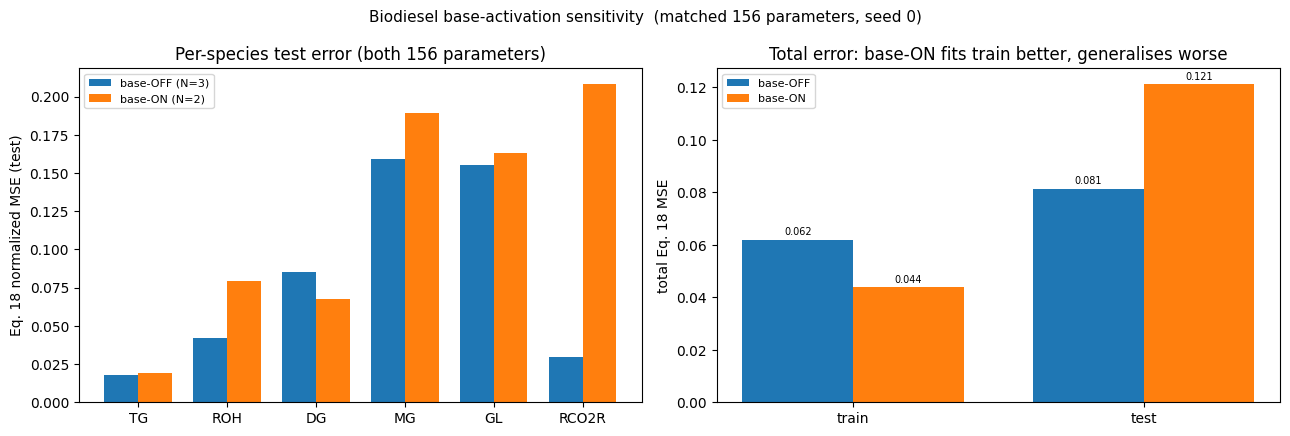

saved /Users/berke/Desktop/University/TU_Wien-MSC/2026S/Interdisciplinary_Project/development/chemkan-tuwien/results/reproduction/tables/biodiesel_base_on_vs_off.csv


In [11]:
# Comparison plot + table: per-species test error and total train/test error, OFF vs ON.
OFF, ON = "base-OFF (main, N=3)", "base-ON (matched, N=2)"
off_test, on_test = cmp[OFF]["test"][1], cmp[ON]["test"][1]
x, w = np.arange(len(species)), 0.38

fig, ax = plt.subplots(1, 2, figsize=(13, 4.4))
ax[0].bar(x - w / 2, off_test, w, color="tab:blue", label="base-OFF (N=3)")
ax[0].bar(x + w / 2, on_test, w, color="tab:orange", label="base-ON (N=2)")
ax[0].set_xticks(x); ax[0].set_xticklabels(species)
ax[0].set_ylabel("Eq. 18 normalized MSE (test)")
ax[0].set_title("Per-species test error (both 156 parameters)")
ax[0].legend(fontsize=8)

splits = ["train", "test"]; xt = np.arange(2)
off_tot = [cmp[OFF][s][0] for s in splits]; on_tot = [cmp[ON][s][0] for s in splits]
bo = ax[1].bar(xt - w / 2, off_tot, w, color="tab:blue", label="base-OFF")
bn = ax[1].bar(xt + w / 2, on_tot, w, color="tab:orange", label="base-ON")
ax[1].set_xticks(xt); ax[1].set_xticklabels(splits)
ax[1].set_ylabel("total Eq. 18 MSE")
ax[1].set_title("Total error: base-ON fits train better, generalises worse")
ax[1].legend(fontsize=8)
for bars in (bo, bn):
    ax[1].bar_label(bars, fmt="%.3f", fontsize=7, padding=2)

fig.suptitle("Biodiesel base-activation sensitivity  (matched 156 parameters, seed 0)", fontsize=11)
fig.tight_layout()
if SAVE_FIGURES:
    for ext in ("pdf", "png"):
        fig.savefig(FIG_DIR / f"biodiesel_base_on_vs_off.{ext}", dpi=300, bbox_inches="tight")
    print("saved", FIG_DIR / "biodiesel_base_on_vs_off.png")
plt.show()

# machine-readable table
p = TABLE_DIR / "biodiesel_base_on_vs_off.csv"
with p.open("w", newline="") as f:
    wr = csv.writer(f)
    wr.writerow(["metric", "base_off", "base_on"])
    wr.writerow(["parameters", n_params, n_params_on])
    wr.writerow(["train_total_mse", f"{cmp[OFF]['train'][0]:.6f}", f"{cmp[ON]['train'][0]:.6f}"])
    wr.writerow(["test_total_mse", f"{cmp[OFF]['test'][0]:.6f}", f"{cmp[ON]['test'][0]:.6f}"])
    for k, sp in enumerate(species):
        wr.writerow([f"test_{sp}_mse", f"{off_test[k]:.6f}", f"{on_test[k]:.6f}"])
print("saved", p)


### What the base-ON comparison shows

| | base-OFF (main, N=3) | base-ON (matched, N=2) |
|---|---|---|
| parameters | 156 | 156 |
| train MSE | 0.062 | **0.044** |
| test MSE | **0.081** | 0.121 |
| gen. gap (test − train) | +0.019 | +0.077 |

At matched parameter count, **base-ON fits the training data better** (0.044 < 0.062) but
**generalises worse** (test 0.121 > 0.081), with a ~4× larger train→test gap — a classic
**overfitting** signature, concentrated on RCO2R and ROH. The two 156-parameter readings
are therefore **not equivalent**: the extra base-activation flexibility is spent memorising
the training trajectories rather than the underlying model.

This **supports the base-OFF inference** on two independent grounds: (1) it is the reading
consistent with the paper's explicit three-point grids (base-ON at N = 3 would be 208, not
156), and (2) at matched parameter count it generalises better here. **Caveat:** single
seed — a firmer conclusion would average over several seeds.

---
## Figures 3, 5A, 5B and 6 — completed noise sweeps

Figures 5 and 6 now use corrected DeepONet checkpoints. The original ChemKAN runs and
clean replay remain unchanged. The clean replay supplies both curves for ChemKAN's 0%
Figure-5B panel, while B0 remains the 0% result for Figures 3 and 5A.

The following cell verifies all 19 manifest entries (14 DeepONet + 5 fixed-n_mu=2 points),
including saved configs, checkpoint/data hashes, contiguous epoch histories and the
h=4 snapshot's actual step. It rebuilds analysis tables and both Figure-4 plots without
training. Figure-5A losses come from final checkpoints, after the last optimizer update;
the last history row describes the state before that update.

In [12]:
import csv, sys, json, subprocess, numpy as np, torch
import matplotlib.pyplot as plt
sys.path.insert(0, str(ROOT / "deeponet"))

TAB = ROOT / "results/reproduction/tables"
CKB = ROOT / "results/reproduction/chemkan/biodiesel"
DON_VERSION = "reference_final_trunk_relu"
DON = ROOT / "results/reproduction/baselines/deeponet/biodiesel" / DON_VERSION / "noise"
FIGB = ROOT / "results/reproduction/figures/biodiesel"; FIGB.mkdir(parents=True, exist_ok=True)

def history(run_dir):
    r = list(csv.DictReader(open(run_dir / "history.csv")))
    return (np.array([float(x["epoch"]) for x in r]),
            np.array([float(x["total_loss"]) for x in r]),
            np.array([float(x["test_mse_clean"]) for x in r]))

def chemkan_run(pct):
    """B0 is the established 0 % result; the replay is Fig.-5B history only."""
    return CKB / "main/direct_autograd_seed0" if pct == 0 else CKB / f"noise/noise{pct:02d}_seed0"

subprocess.run([sys.executable, str(ROOT / "chemkan/scripts/diagnostics/refresh_biodiesel_reports.py")],
               cwd=ROOT, check=True)

metrics = [r for r in csv.DictReader(open(TAB / "biodiesel_fig5a_metrics.csv"))]
levels = sorted({int(r["noise_percent"]) for r in metrics if r["role"] == "plotted"})
print("noise levels:", levels)
print("runs:", len([r for r in metrics if r["role"] == "plotted"]), "plotted +",
      len([r for r in metrics if r["role"] != "plotted"]), "replay (not plotted in 5A)")
assert all(r["architecture_version"] == DON_VERSION for r in metrics if r["model"] == "DeepONet")
print("DeepONet architecture:", DON_VERSION)

Verified 19 points; refreshed corrected DeepONet noise/scaling tables and fixed-n_mu=2 Figure 4.


noise levels: [0, 1, 2, 3, 5, 7, 10, 15]
runs: 16 plotted + 1 replay (not plotted in 5A)
DeepONet architecture: reference_final_trunk_relu


### Figure 3 — the paper's explicit unseen condition

`TG0 = 1.94`, `ROH0 = 1.43`, all other species zero, `T = 334.8 K` (PAPER EXPLICIT). This
state is not in the 10-case test split, so it is generated as a dedicated artifact with the
same ODE, solver settings and noise convention as the dataset; the canonical split is
untouched. Predictions are closed-loop integrations from the initial condition on a dense
601-point grid — no intermediate observations are used.

Each panel reports the species loss against **clean truth** and **observations** at the
30 observation times, using train-only min-max normalization and summing squared errors
over time. The mean of the six species losses in a column gives the Eq. 18 trajectory
loss for that reference (Eq. 22 for clean truth); the dense grid is used only for plotting.

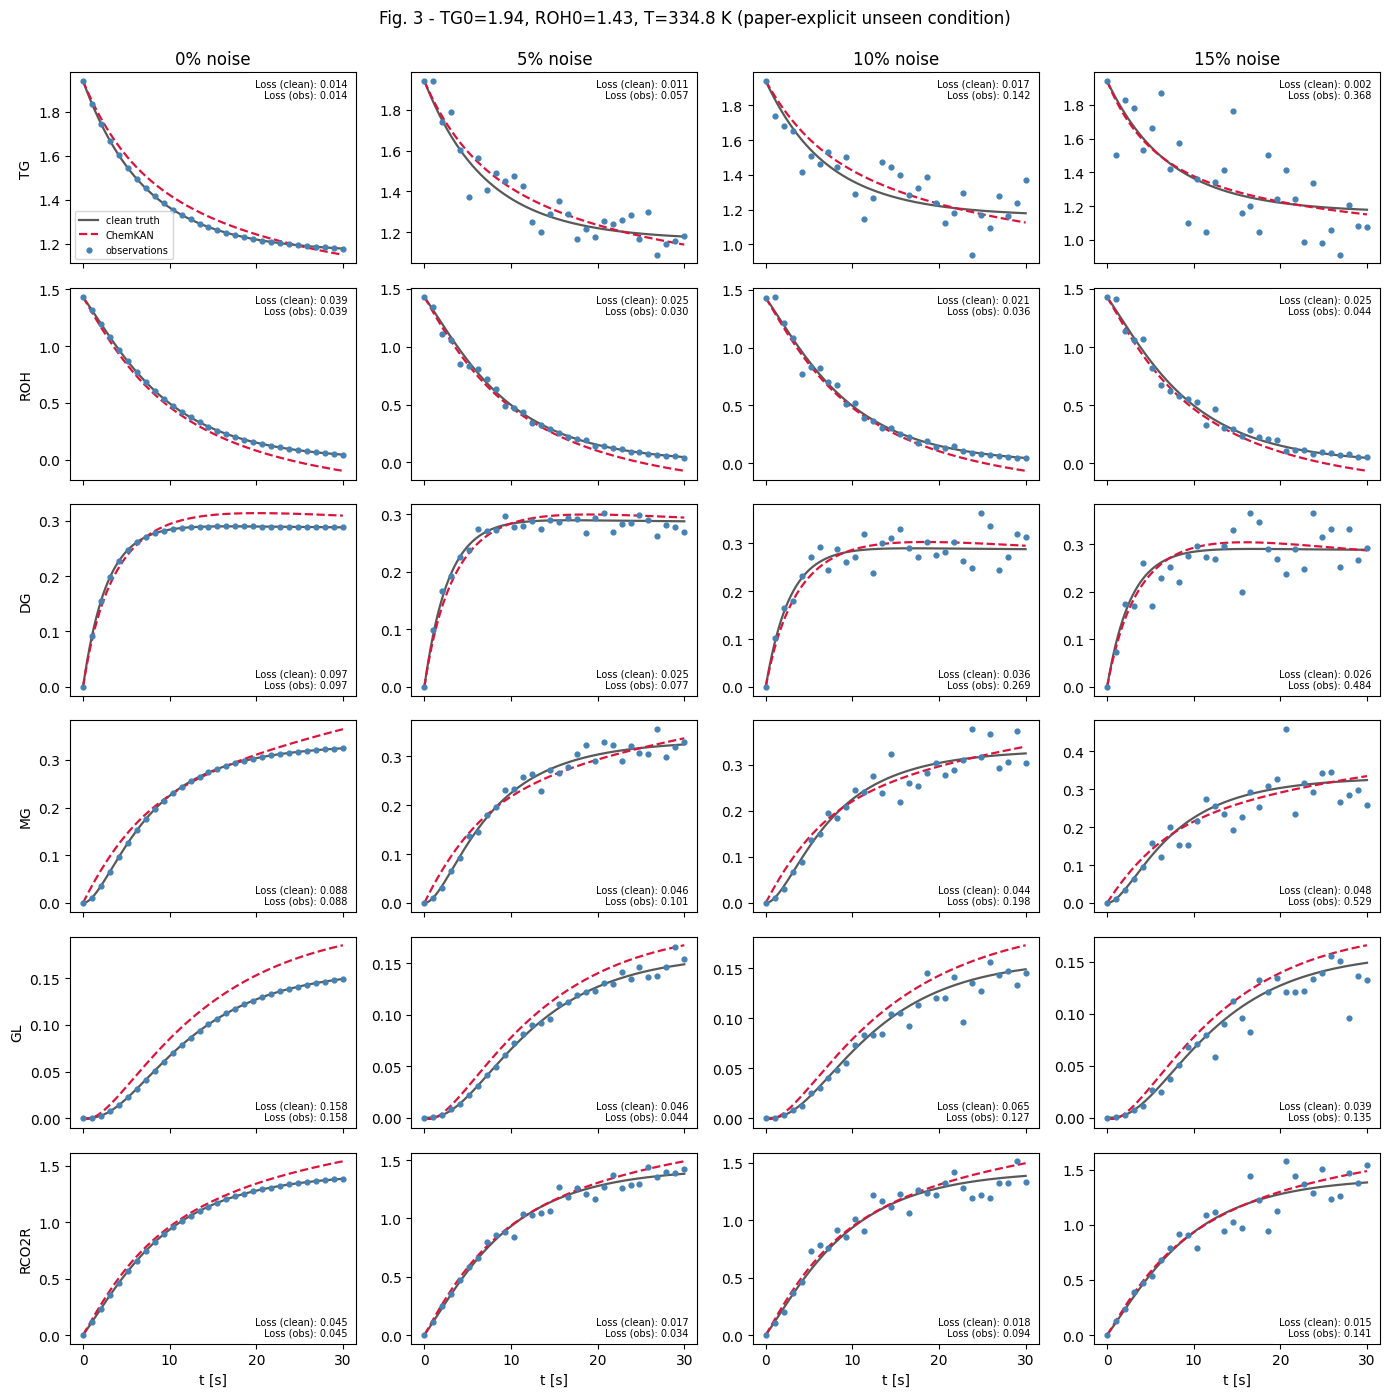

In [13]:
from evaluate_biodiesel import build_kinetic_core, solver_from_ckpt, integrate_biodiesel
from _data import load_biodiesel, load_input_scaling
from chemkan.normalization import MinMaxNormalizer

art = np.load(ROOT / "chemkan/data/generated/biodiesel_fig3_condition.npz", allow_pickle=True)
td, tobs = art["t_dense"], art["t"]
truth_d, spec3 = art["states_dense"], [str(s) for s in art["species"]]
y0_3, T3 = art["y0"], float(art["T"])

# Same train-only normalization and time-sum reduction as the Eq. 18 loss.
train3 = load_biodiesel("train")
loss_norm3 = MinMaxNormalizer(train3["u_min"], train3["u_max"])
truth_obs_norm3 = loss_norm3.normalize(torch.as_tensor(art["states"], dtype=torch.float32))

fig, axes = plt.subplots(6, 4, figsize=(14, 14), sharex=True)
for c, pct in enumerate([0, 5, 10, 15]):
    ck = torch.load(chemkan_run(pct) / "checkpoint_final.pt", map_location="cpu", weights_only=False)
    core = build_kinetic_core(ck, len(spec3), "cpu")
    input_norm3, solver3 = load_input_scaling(ck, "cpu"), solver_from_ckpt(ck)
    pred = integrate_biodiesel(core, input_norm3, solver3,
                               torch.as_tensor(y0_3, dtype=torch.float32).unsqueeze(0),
                               torch.tensor([T3]), torch.as_tensor(td, dtype=torch.float32),
                               "cpu")[:, 0, :].numpy()
    noisy = art[f"states_noise{pct:02d}"]
    # Evaluate at the actual observation times; the dense grid is for plotting.
    pred_obs3 = integrate_biodiesel(core, input_norm3, solver3,
                                    torch.as_tensor(y0_3, dtype=torch.float32).unsqueeze(0),
                                    torch.tensor([T3]), torch.as_tensor(tobs, dtype=torch.float32),
                                    "cpu")[:, 0, :]
    pred_obs_norm3 = loss_norm3.normalize(pred_obs3)
    noisy_norm3 = loss_norm3.normalize(torch.as_tensor(noisy, dtype=torch.float32))
    loss_clean3 = ((pred_obs_norm3 - truth_obs_norm3) ** 2).sum(dim=0).numpy()
    loss_obs3 = ((pred_obs_norm3 - noisy_norm3) ** 2).sum(dim=0).numpy()
    for r, sp in enumerate(spec3):
        ax = axes[r, c]
        ax.plot(td, truth_d[:, r], color="0.35", lw=1.6, label="clean truth")
        ax.plot(td, pred[:, r], color="crimson", lw=1.6, ls="--", label="ChemKAN")
        ax.scatter(tobs, noisy[:, r], s=12, color="steelblue", zorder=3, label="observations")
        ax.text(0.97, 0.97 if r < 2 else 0.03,
                f"Loss (clean): {loss_clean3[r]:.3f}\nLoss (obs): {loss_obs3[r]:.3f}",
                transform=ax.transAxes, ha="right", va="top" if r < 2 else "bottom", fontsize=7,
                bbox=dict(facecolor="white", edgecolor="none", alpha=0.8))
        if c == 0: ax.set_ylabel(sp)
        if r == 0: ax.set_title(f"{pct}% noise")
        if r == 5: ax.set_xlabel("t [s]")
axes[0, 0].legend(fontsize=7, loc="lower left")
fig.suptitle(f"Fig. 3 - TG0={y0_3[0]}, ROH0={y0_3[1]}, T={T3} K (paper-explicit unseen condition)", y=0.995)
fig.tight_layout()
if SAVE_FIGURES:
    for e in ("pdf", "png"):
        fig.savefig(FIGB / f"fig03_biodiesel_noise_columns.{e}", dpi=150, bbox_inches="tight")
plt.show()

**Reading Figure 3.** The reconstruction is qualitatively right at every noise level, and
visibly *not* exact even at 0 %: the 0 % prediction drives ROH negative at late times and
overshoots GL and R'CO2R. That is an unphysical excursion, not a plotting artifact — the
kinetic core is unconstrained in sign. The noisy-trained columns are not visibly worse than
the clean one, which is the paper's qualitative robustness claim.

### Figure 5A — noise robustness

Three metrics per model and noise level, all from the final checkpoint. The two test
metrics use the *same* predicted trajectories and differ only in their target: the noisy
observations (Eq. 18) versus the clean underlying trajectories (Eq. 22). At 0 % the two
coincide exactly.

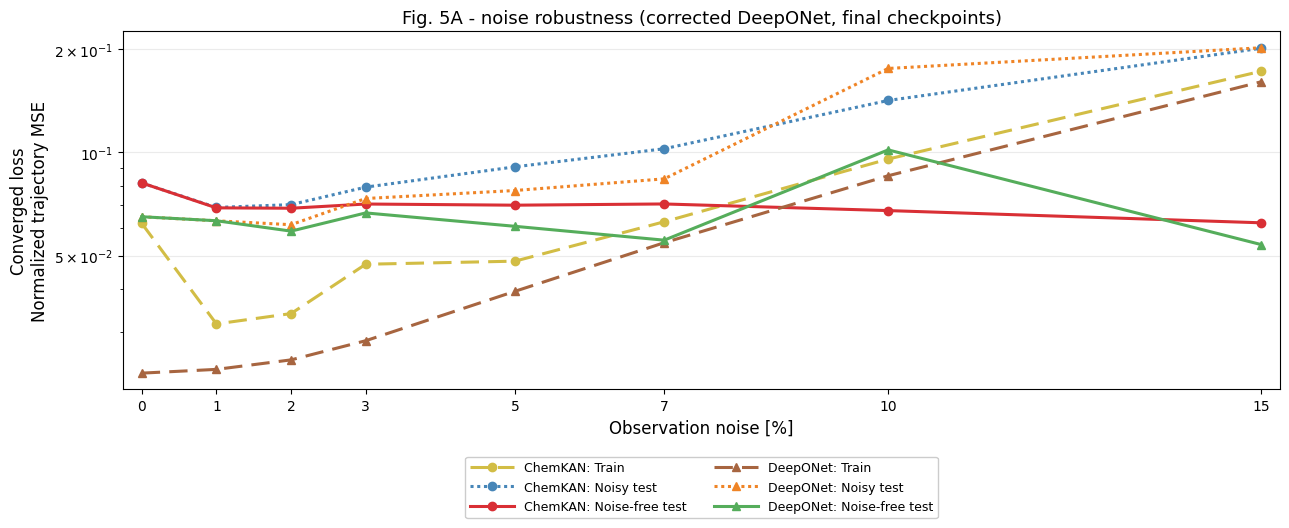

noise    CK train     CK test    CK clean    DO train     DO test    DO clean
   0%  6.2017e-02  8.1401e-02  8.1401e-02  2.2697e-02  6.4866e-02  6.4866e-02
   1%  3.1584e-02  6.9036e-02  6.8855e-02  2.3278e-02  6.3123e-02  6.3151e-02
   2%  3.3856e-02  7.0366e-02  6.8679e-02  2.4812e-02  6.1489e-02  5.8892e-02
   3%  4.7151e-02  7.9131e-02  7.0651e-02  2.8215e-02  7.3317e-02  6.6552e-02
   5%  4.8137e-02  9.0692e-02  7.0104e-02  3.9319e-02  7.7360e-02  6.0829e-02
   7%  6.2722e-02  1.0241e-01  7.0680e-02  5.4488e-02  8.3659e-02  5.5425e-02
  10%  9.5558e-02  1.4161e-01  6.7605e-02  8.5416e-02  1.7556e-01  1.0162e-01
  15%  1.7237e-01  2.0109e-01  6.2277e-02  1.6059e-01  2.0175e-01  5.3794e-02


In [14]:
def series(model, key):
    rows = [r for r in metrics if r["role"] == "plotted" and r["model"] == model]
    return [float(next(r for r in rows if int(r["noise_percent"]) == p)[key]) for p in levels]

from matplotlib.ticker import LogLocator, LogFormatterSciNotation

# Shared by Figures 5A and 5B: model colors, metric line patterns.
FIG5_COLORS = {
    "ChemKAN": {"train_mse_noisy": "#D2BD45", "test_mse_noisy": "#4786B8",
                "test_mse_clean": "#D92F35"},
    "DeepONet": {"train_mse_noisy": "#A76540", "test_mse_noisy": "#EF8426",
                 "test_mse_clean": "#55AD5B"},
}
FIG5_LINES = {"train_mse_noisy": (0, (6, 3)),
              "test_mse_noisy": (0, (1, 1.2)), "test_mse_clean": "-"}
FIG5_LABELS = {"train_mse_noisy": "Train", "test_mse_noisy": "Noisy test",
               "test_mse_clean": "Noise-free test"}

fig, ax = plt.subplots(figsize=(13, 5.5))
for model, marker in (("ChemKAN", "o"), ("DeepONet", "^")):
    for key in ("train_mse_noisy", "test_mse_noisy", "test_mse_clean"):
        ax.plot(levels, series(model, key), color=FIG5_COLORS[model][key],
                ls=FIG5_LINES[key], lw=2.2, marker=marker, ms=6,
                label=f"{model}: {FIG5_LABELS[key]}")
ax.set_xlabel("Observation noise [%]", fontsize=12)
ax.set_ylabel("Converged loss\nNormalized trajectory MSE", fontsize=12)
ax.set_yscale("log")
ax.yaxis.set_major_locator(LogLocator(base=10, subs=(1, 2, 5)))
ax.yaxis.set_major_formatter(LogFormatterSciNotation(base=10, labelOnlyBase=False,
                                                    minor_thresholds=(np.inf, np.inf)))
ax.set_xticks(levels)
ax.set_xlim(min(levels) - 0.25, max(levels) + 0.25)
ax.tick_params(axis="both", which="major", labelsize=10)
ax.set_title("Fig. 5A - noise robustness (corrected DeepONet, final checkpoints)", fontsize=13)
# Matplotlib fills columns in order: ChemKAN on the left, DeepONet on the right.
ax.legend(ncol=2, fontsize=9, loc="upper center", bbox_to_anchor=(0.5, -0.17),
          handlelength=3.5, columnspacing=2.2, framealpha=1)
ax.grid(axis="y", which="major", alpha=0.25)
fig.tight_layout()
if SAVE_FIGURES:
    for e in ("pdf", "png"):
        fig.savefig(FIGB / f"fig05a_biodiesel_noise_robustness.{e}", dpi=150, bbox_inches="tight")
plt.show()

print(f"{'noise':>5} {'CK train':>11} {'CK test':>11} {'CK clean':>11} "
      f"{'DO train':>11} {'DO test':>11} {'DO clean':>11}")
for i, p in enumerate(levels):
    print(f"{p:4d}% " + " ".join(f"{series(m, k)[i]:11.4e}" for m in ("ChemKAN", "DeepONet")
                                  for k in ("train_mse_noisy", "test_mse_noisy", "test_mse_clean")))

### Figure 5B — loss dynamics

Per-epoch noisy training MSE and noise-free test MSE, recorded every epoch by an
evaluation-only callback that runs under `no_grad`, takes no optimizer step, writes no
parameter and saves/restores the RNG state. It is evaluated *inside* the loss function, so
each logged test value belongs to exactly the parameter state that produced that epoch's
training loss. Training losses are bitwise identical with and without it.

The **0 % panel comes entirely from the clean replay** — both curves, one parameter
trajectory. Raw per-epoch values are plotted faintly underneath a **display-only** moving
average; the smoothing is cosmetic and the raw values are what is stored.

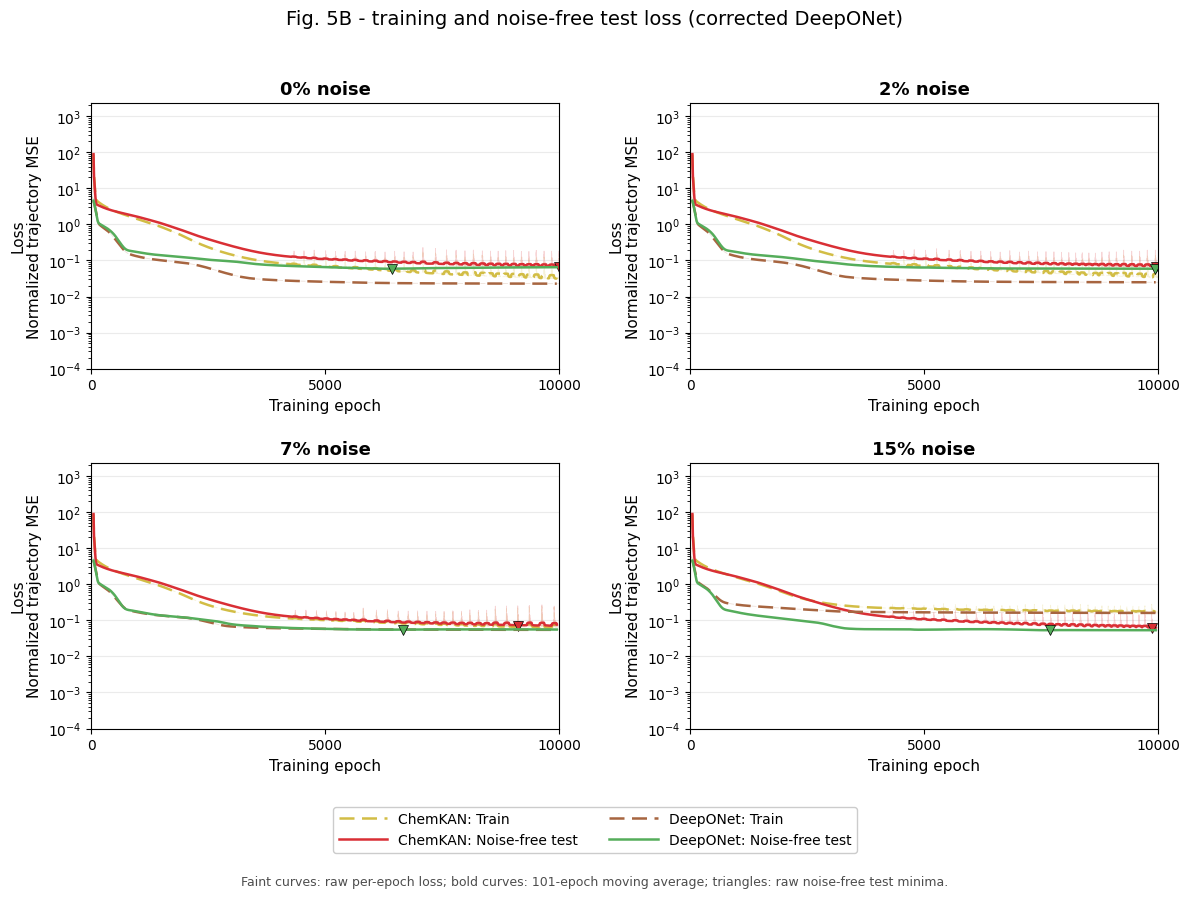

late-training oscillation span (last 20% of epochs, RAW):
noise model       train span  clean-test span
   0% ChemKAN         0.1188           0.1273
   0% DeepONet        0.0004           0.0029
   2% ChemKAN         0.1066           0.1274
   2% DeepONet        0.0004           0.0010
   7% ChemKAN         0.1894           0.2000
   7% DeepONet        0.0003           0.0019
  15% ChemKAN         0.1045           0.1164
  15% DeepONet        0.0011           0.0017


In [15]:
K = 101
smooth = lambda y: np.convolve(y, np.ones(K) / K, mode="valid")
off = (K - 1) // 2

# Reuse the palette and line patterns from the Figure 5A cell above.
fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharey=True)
osc = {}
for ax, pct in zip(axes.flat, (0, 2, 7, 15)):
    # 0 %: the replay, which reproduces B0 bitwise and adds the missing test columns.
    ck_dir = CKB / "noise/clean_replay_seed0" if pct == 0 else CKB / f"noise/noise{pct:02d}_seed0"
    for name, d in (("ChemKAN", ck_dir), ("DeepONet", DON / f"noise{pct:02d}_seed0")):
        e, tr, te = history(d)
        late = e >= 0.8 * e.max()
        osc[(name, pct)] = (tr[late].max() - tr[late].min(), te[late].max() - te[late].min())
        for key, values in (("train_mse_noisy", tr), ("test_mse_clean", te)):
            color = FIG5_COLORS[name][key]
            ax.plot(e, values, color=color, ls=FIG5_LINES[key], lw=0.6, alpha=0.20)  # RAW
            ax.plot(e[off:len(e) - off], smooth(values), color=color, ls=FIG5_LINES[key],
                    lw=1.8, label=f"{name}: {FIG5_LABELS[key]}")
        i = int(np.argmin(te))
        ax.plot(e[i], te[i], "v", color=FIG5_COLORS[name]["test_mse_clean"],
                ms=7, mec="k", mew=0.5)
    ax.set_yscale("log")
    ax.yaxis.set_major_locator(LogLocator(base=10, numticks=12))
    ax.yaxis.set_major_formatter(LogFormatterSciNotation(base=10, labelOnlyBase=True))
    ax.set_xlabel("Training epoch", fontsize=11)
    ax.set_ylabel("Loss\nNormalized trajectory MSE", fontsize=11)
    ax.set_xticks([0, 5000, 10000])
    ax.set_xlim(0, 10000)
    ax.tick_params(axis="both", which="major", labelsize=10, labelleft=True)
    ax.set_title(f"{pct}% noise", fontsize=13, fontweight="bold")
    ax.grid(axis="y", which="major", alpha=0.25)
# Extend the shared axis to the reference's 10^-4 scale without changing any loss values.
# Keep the automatically determined upper limit so the initial raw losses remain visible.
axes[0, 0].set_ylim(bottom=1e-4)
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, ncol=2, loc="lower center", bbox_to_anchor=(0.5, 0.04),
           fontsize=10, handlelength=3.5, columnspacing=2.2, framealpha=1)
fig.suptitle("Fig. 5B - training and noise-free test loss (corrected DeepONet)", fontsize=14, y=0.985)
fig.text(0.5, 0.012, f"Faint curves: raw per-epoch loss; bold curves: {K}-epoch moving average; "
         "triangles: raw noise-free test minima.", ha="center", fontsize=9, color="0.3")
fig.tight_layout(rect=(0, 0.12, 1, 0.96), h_pad=2.0, w_pad=2.0)
if SAVE_FIGURES:
    for e_ in ("pdf", "png"):
        fig.savefig(FIGB / f"fig05b_biodiesel_loss_dynamics.{e_}", dpi=150, bbox_inches="tight")
plt.show()

print("late-training oscillation span (last 20% of epochs, RAW):")
print(f"{'noise':>5} {'model':9s} {'train span':>12s} {'clean-test span':>16s}")
for (n, pc), (a, b) in sorted(osc.items(), key=lambda kv: (kv[0][1], kv[0][0])):
    print(f"{pc:4d}% {n:9s} {a:12.4f} {b:16.4f}")

**Overfitting is assessed from both curves.** A test minimum alone is insufficient.
We retain the same diagnostic criterion: test loss rises >10% above its minimum,
201-epoch smoothed training loss falls a further >5%, and the test minimum occurs
before 90% of the epoch budget. The smoothing is centered and clamped to its available
endpoints. These thresholds and window are **our diagnostic choice**, not the paper's.

The measurements below are recomputed from the selected histories. A run not meeting
this criterion is not thereby proved free of overfitting. The raw late-training spans
above show how much fixed-checkpoint comparisons can fluctuate. **The cause of the
oscillation is NOT established**; attributing it to a solver, architecture or optimizer
would require additional controlled experiments.

In [16]:
from IPython.display import Markdown, display
assessment = json.loads((TAB / "biodiesel_fig5b_overfit_assessment.json").read_text())
lines = ["| Model/noise | Test minimum epoch | Test rise | Training fall | Meets criterion |",
         "|---|---:|---:|---:|---|"]
for name, a in assessment.items():
    lines.append(f"| {name} | {a['min_epoch']} | {a['test_rise']:.1%} | "
                 f"{a['train_fall_after_min']:.1%} | {a['overfitting']} |")
display(Markdown("\n".join(lines)))

| Model/noise | Test minimum epoch | Test rise | Training fall | Meets criterion |
|---|---:|---:|---:|---|
| ChemKAN_0pct | 9986 | 125.3% | 0.0% | False |
| ChemKAN_2pct | 9960 | 5.2% | 0.0% | False |
| ChemKAN_7pct | 9118 | 3.5% | 3.6% | False |
| ChemKAN_15pct | 9881 | 1.6% | 0.0% | False |
| DeepONet_0pct | 6429 | 10.8% | 3.5% | False |
| DeepONet_2pct | 9930 | 0.3% | 0.0% | False |
| DeepONet_7pct | 6659 | 1.2% | 1.8% | False |
| DeepONet_15pct | 7692 | 0.1% | 0.9% | False |

### Figure 6 — 15 % noise profiles at the Figure 3 condition

Use the existing 15 % noise ChemKAN and DeepONet checkpoints at
`TG0 = 1.94`, `ROH0 = 1.43`, all other species zero, and `T = 334.8 K`, matching our
Figure 3. Clean truth and 15 % noisy observations come from the same dedicated Figure 3
artifact; this condition was not used to train the models.

The initial concentrations are consistent with the paper's Figure 6 curves. Reusing
Figure 3's temperature for Figure 6 is a reproduction plotting choice; that temperature
has not been independently confirmed for the paper's Figure 6.

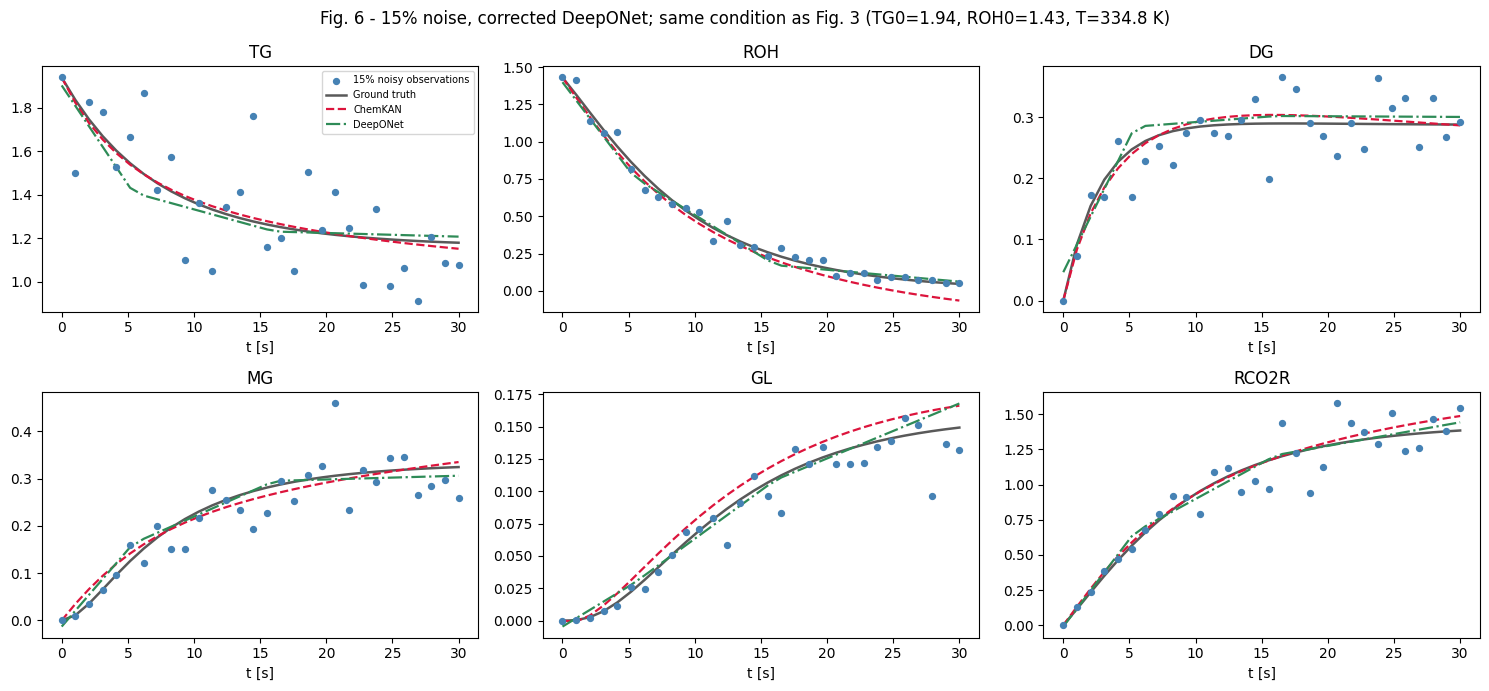

Figure 3 condition: TG0=1.94 ROH0=1.43 T=334.8 K; all other species start at 0
ChemKAN: clean-trajectory Eq. 18 MSE at this condition = 0.0256604
DeepONet: clean-trajectory Eq. 18 MSE at this condition = 0.0262176


In [17]:
import biodiesel_deeponet as bdon
from evaluate_biodiesel_deeponet import build_model
from chemkan.normalization import MinMaxNormalizer
from _data import load_input_scaling
from evaluate_biodiesel import build_kinetic_core, solver_from_ckpt, integrate_biodiesel

# Reuse Figure 3's condition, clean truth, and stored 15% noise realization.
with np.load(ROOT / "chemkan/data/generated/biodiesel_fig3_condition.npz", allow_pickle=True) as art6:
    t6, spec6 = art6["t"], [str(s) for s in art6["species"]]
    truth6, noisy6 = art6["states"], art6["states_noise15"]
    y06 = torch.as_tensor(art6["y0"], dtype=torch.float32)
    T6 = torch.tensor(float(art6["T"]), dtype=torch.float32)
t6_tensor = torch.as_tensor(t6, dtype=torch.float32)

ck = torch.load(CKB / "noise/noise15_seed0/checkpoint_final.pt", map_location="cpu", weights_only=False)
core = build_kinetic_core(ck, len(spec6), "cpu")
pred_ck = integrate_biodiesel(core, load_input_scaling(ck, "cpu"), solver_from_ckpt(ck),
                              y06.unsqueeze(0), T6.reshape(1), t6_tensor, "cpu")[:, 0, :].numpy()

dck = torch.load(DON / "noise15_seed0/checkpoint_final.pt", map_location="cpu", weights_only=False)
dmod = build_model(dck, "cpu"); nrm = dck["normalization"]
assert dmod.architecture_version == DON_VERSION
full_n = MinMaxNormalizer(nrm["u_min"], nrm["u_max"]); loss_n = full_n.subset(slice(0, len(spec6)))
b6, tau6 = bdon.prepare_inputs({"Y0": y06.unsqueeze(0), "T_const": T6.reshape(1), "t": t6_tensor},
                               full_n, float(nrm["t_end_s"]))
with torch.no_grad():
    pred_do = loss_n.denormalize(dmod(b6, tau6))[:, 0, :].numpy()   # inverse-transform for physical plot

fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for k, sp in enumerate(spec6):
    ax = axes[k // 3, k % 3]
    ax.scatter(t6, noisy6[:, k], s=18, color="steelblue", zorder=3, label="15% noisy observations")
    ax.plot(t6, truth6[:, k], color="0.35", lw=1.8, label="Ground truth")
    ax.plot(t6, pred_ck[:, k], color="crimson", lw=1.6, ls="--", label="ChemKAN")
    ax.plot(t6, pred_do[:, k], color="seagreen", lw=1.6, ls="-.", label="DeepONet")
    ax.set_title(sp); ax.set_xlabel("t [s]")
axes[0, 0].legend(fontsize=7)
fig.suptitle(f"Fig. 6 - 15% noise, corrected DeepONet; same condition as Fig. 3 "
             f"(TG0={float(y06[0]):.2f}, ROH0={float(y06[1]):.2f}, T={float(T6):.1f} K)")
fig.tight_layout()
if SAVE_FIGURES:
    for e_ in ("pdf", "png"):
        fig.savefig(FIGB / f"fig06_biodiesel_15pct_profiles.{e_}", dpi=150, bbox_inches="tight")
plt.show()
print(f"Figure 3 condition: TG0={float(y06[0]):.2f} ROH0={float(y06[1]):.2f} T={float(T6):.1f} K; "
      f"all other species start at 0")
profile_metrics = {}
for name, prediction in (("ChemKAN", pred_ck), ("DeepONet", pred_do)):
    prediction_n = loss_n.normalize(torch.as_tensor(prediction).unsqueeze(1))
    truth_n = loss_n.normalize(torch.as_tensor(truth6).unsqueeze(1))
    profile_metrics[name] = float(trajectory_mse(prediction_n, truth_n))
    print(f"{name}: clean-trajectory Eq. 18 MSE at this condition = {profile_metrics[name]:.6g}")
with (TAB / "biodiesel_fig6_profile_metrics.json").open("w") as f:
    json.dump({"initial_state": y06.tolist(), "temperature_K": float(T6),
               "deeponet_version": DON_VERSION, "clean_mse": profile_metrics,
               "condition": "Figure 3 dedicated unseen condition", "observation_times": len(t6)}, f, indent=2)

### Comparison against the paper's reported findings

The following biodiesel rows are refreshed from the current checkpoint evaluations and
histories in `results/reproduction/tables/reproduction_comparison.csv`. Hydrogen rows
are preserved for Notebook 08. Legacy comparison rows are archived separately.

**Evaluation completed does not mean paper result matched.** Activation placement,
parameter counts, fitting scope and the Figure-6 condition retain the stated caveats.

In [18]:
comp = [r for r in csv.DictReader(open(TAB / "reproduction_comparison.csv"))
        if r["figure"] in ("Fig. 3", "Fig. 4", "Fig. 5A", "Fig. 5B", "Fig. 6")]
for r in comp:
    print(f"[{r['figure']:8s}] {r['status'].upper()}")
    print(f"    paper: {r['paper_result']} = {r['paper_value']}")
    print(f"    ours : {r['our_result']}")
    print(f"    -> {r['remaining_difference']}")
    print(f"    artifact: {r['artifact_path']}\n")

[Fig. 3  ] EVALUATION COMPLETED; QUALITATIVELY SIMILAR, NOT QUANTITATIVELY MATCHED
    paper: Smooth reconstruction of the explicit unseen condition at 0/5/10/15% noise = qualitative
    ours : all four columns produced for TG0=1.94, ROH0=1.43, T=334.8 K; all six species
    -> Reconstruction is visibly imperfect even at 0%: ROH is driven negative at late times and GL / R'CO2R overshoot. The noisy columns are not visibly worse than the clean one.
    artifact: results/reproduction/figures/biodiesel/fig03_biodiesel_noise_columns.pdf

[Fig. 4  ] EVALUATION COMPLETED; FITTING SCOPE DIFFERS
    paper: ChemKAN training scaling slope = -1.0
    ours : -0.41 (R2 0.19, SE 0.49)
    -> Descriptive all-point regression; paper uses a pre-saturation subset. Current DeepONet uses reference_final_trunk_relu; legacy tables are archived.
    artifact: results/reproduction/tables/biodiesel_fig4_fits.csv

[Fig. 4  ] EVALUATION COMPLETED; FITTING SCOPE DIFFERS
    paper: ChemKAN testing scaling slope = -

---

## Figure 4 — neural scaling

Widths were fixed by **digitizing the paper's own figure** rather than guessed
(`docs/fig4_width_matrix.md`, `chemkan/scripts/diagnostics/digitize_paper_fig4.py`). ChemKAN
h = 2, 3, 4, 10, 17 → 78, 117, 156, 390, 663 measured parameters at 5,000 epochs;
DeepONet w = 3, 5, 6, 8, 10, 13 → 85, 169, 220, 340, 484, 745 at 50,000 epochs. These
**reconstruct the plotted parameter range; they are not exact paper-specified
architectures.** The paper's ≈650-parameter ChemKAN marker matches no `39h` width and is
preserved as an unexplained discrepancy — h=17 (663) is merely the nearest feasible one.

**h = 4 is reused, not retrained**: it is the clean replay's `checkpoint_epoch_5000.pt`,
the model after exactly 5,000 optimizer steps under every Fig.-4 setting.
The default DeepONet points below use `reference_final_trunk_relu`. The primary ChemKAN
sweep retains `n_mu=ceil(h/2)`; the additional plot below fixes `n_mu=2` at every width.

In [19]:
import subprocess
FIT = TAB / "biodiesel_fig4_fits.csv"
PTS = TAB / "biodiesel_fig4_points.csv"
pts4 = list(csv.DictReader(open(PTS))); fits4 = list(csv.DictReader(open(FIT)))

print(f"{'model':9s} {'w':>3s} {'params':>7s} {'train(final)':>13s} {'test(final)':>12s} "
      f"{'train late median':>18s} {'late band':>24s}")
for r in sorted(pts4, key=lambda r: (r["model"], int(r["parameters"]))):
    band = f"[{float(r['train_late_min']):.2e},{float(r['train_late_max']):.2e}]"
    print(f"{r['model']:9s} {int(r['width']):3d} {int(r['parameters']):7d} "
          f"{float(r['train_loss']):13.4e} {float(r['test_loss']):12.4e} "
          f"{float(r['train_loss_late_median']):18.4e} {band:>24s}"
          f"{'  REUSED' if r['reused'] == 'True' else ''}")
print()
for f_ in fits4:
    print(f"{f_['model']:9s} {f_['metric']:23s} slope {float(f_['slope']):+.3f}  "
          f"R2 {float(f_['r_squared']):.3f}  SE {float(f_['std_error']):.3f}  "
          f"n={f_['n_included']}  excluded [{f_['excluded']}]")
print(f"\nmask: {fits4[0]['mask_rule']}")

model       w  params  train(final)  test(final)  train late median                late band
ChemKAN     2      78    3.6699e-01   4.6151e-01         3.9819e-01      [3.67e-01,4.43e-01]
ChemKAN     3     117    4.6852e-02   7.1882e-02         5.4084e-02      [4.69e-02,6.32e-02]
ChemKAN     4     156    6.8374e-02   1.1164e-01         7.5263e-02      [6.75e-02,1.55e-01]  REUSED
ChemKAN    10     390    5.2373e-02   6.4873e-02         4.2398e-02      [3.41e-02,2.13e-01]
ChemKAN    17     663    8.9945e-02   1.4363e-01         1.1085e-01      [8.92e-02,1.40e-01]
DeepONet    3      85    7.5301e-01   8.6424e-01         7.5301e-01      [7.53e-01,7.53e-01]
DeepONet    5     169    3.1512e-01   3.6673e-01         3.1512e-01      [3.15e-01,3.15e-01]
DeepONet    6     220    3.1600e-01   3.8202e-01         3.1600e-01      [3.16e-01,3.16e-01]
DeepONet    8     340    2.1653e-02   7.1903e-02         2.1659e-02      [2.16e-02,2.19e-02]
DeepONet   10     484    1.8074e-01   2.3345e-01         1.807

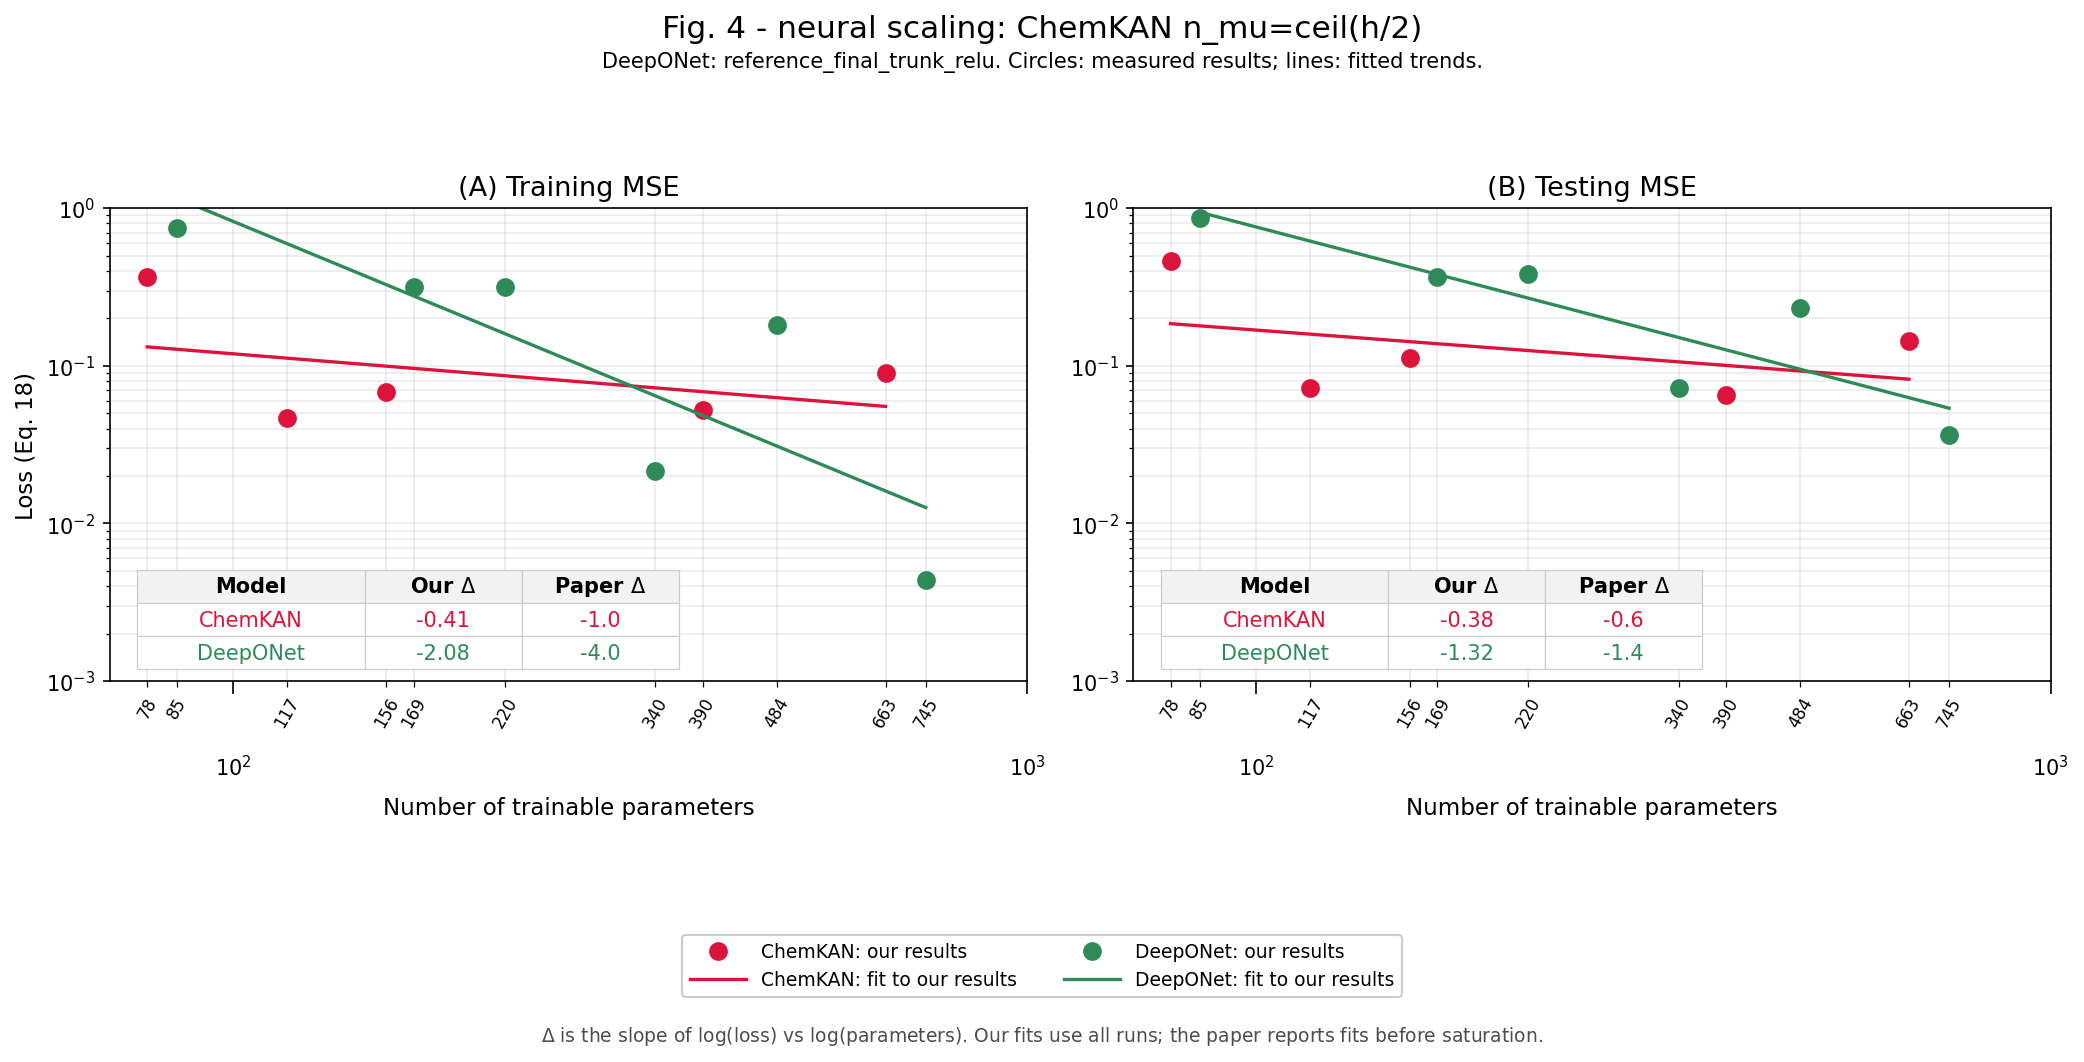

In [20]:
from IPython.display import Image, display
display(Image(filename=str(FIGB / "fig04_biodiesel_neural_scaling.png")))

### Reading Figure 4

The x-axis labels both powers of ten and every measured parameter count. Circles are
checkpoint losses, and solid lines are descriptive regressions through **all points**.
The paper's triangles are omitted; the tables retain its reported slopes for comparison.
The fitting scope differs from the paper's pre-saturation subset, so numerical closeness
of slopes does not establish a reproduced scaling law. R² and standard errors are
reported alongside each fit above. No widths are dropped or retuned after inspection.

A positive Δ means loss increases with parameter count over the measured sweep;
a negative Δ means it decreases. The late-epoch median and raw range are secondary
measurements and do not replace the final-checkpoint loss. A loss history that has
plateaued at a high value does not by itself identify the cause.

## Figure 4 — additional fixed-`n_mu=2` comparison

Every ChemKAN width uses two multiplication nodes, with the same N=3, base-OFF,
seed-0, 5,000-epoch setup. The h=3 run and h=4 epoch-5,000 snapshot are reused;
h=2/10/17 are new runs. Both Figure-4 plots use the **same corrected DeepONet points**.
This is a controlled comparison of the selected n_mu rules, not a paper-specified sweep.

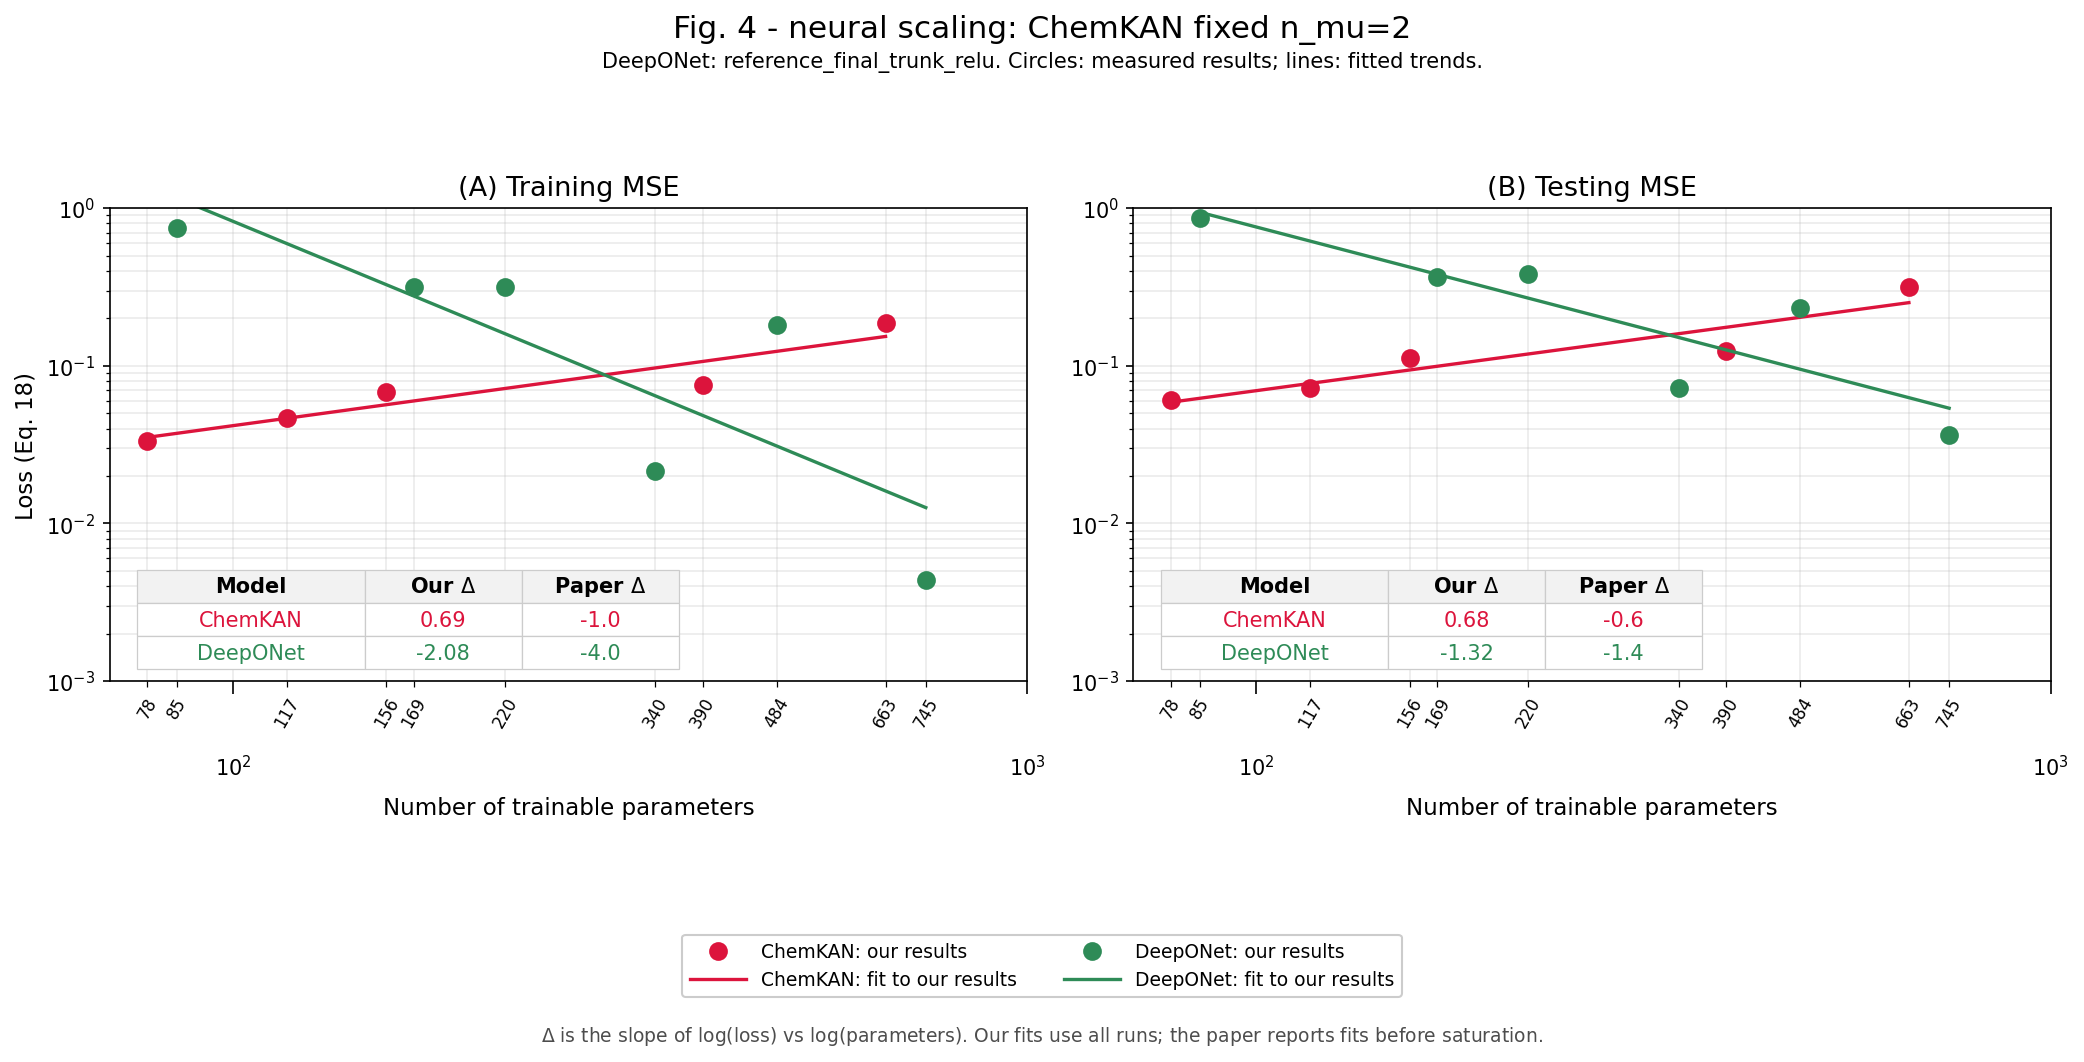

| Width | Parameters | Original n_mu | Original train | n_mu=2 train | Original test | n_mu=2 test | Reused |
|---:|---:|---:|---:|---:|---:|---:|---|
| 2 | 78 | 1 | 0.36699 | 0.033512 | 0.46151 | 0.060541 | False |
| 3 | 117 | 2 | 0.046852 | 0.046852 | 0.071882 | 0.071882 | True |
| 4 | 156 | 2 | 0.068374 | 0.068374 | 0.11164 | 0.11164 | True |
| 10 | 390 | 5 | 0.052373 | 0.075182 | 0.064873 | 0.12339 | False |
| 17 | 663 | 9 | 0.089945 | 0.18726 | 0.14363 | 0.31405 | False |

Fixed n_mu=2 train_loss: delta=+0.689, R2=0.882, SE=0.146; loss increases with width in these runs.
Fixed n_mu=2 test_loss: delta=+0.680, R2=0.873, SE=0.149; loss increases with width in these runs.


In [21]:
pts_nmu2 = list(csv.DictReader((TAB / "biodiesel_fig4_points_nmu2.csv").open()))
fits_nmu2 = list(csv.DictReader((TAB / "biodiesel_fig4_fits_nmu2.csv").open()))
assert all(int(r["n_mu"]) == 2 for r in pts_nmu2 if r["model"] == "ChemKAN")
display(Image(filename=str(FIGB / "fig04_biodiesel_neural_scaling_nmu2.png")))
original = {int(r["width"]): r for r in pts4 if r["model"] == "ChemKAN"}
lines = ["| Width | Parameters | Original n_mu | Original train | n_mu=2 train | Original test | n_mu=2 test | Reused |",
         "|---:|---:|---:|---:|---:|---:|---:|---|"]
for r in sorted((r for r in pts_nmu2 if r["model"] == "ChemKAN"), key=lambda r: int(r["width"])):
    old = original[int(r["width"])]
    lines.append(f"| {r['width']} | {r['parameters']} | {old['n_mu']} | {float(old['train_loss']):.5g} | "
                 f"{float(r['train_loss']):.5g} | {float(old['test_loss']):.5g} | {float(r['test_loss']):.5g} | {r['reused']} |")
display(Markdown("\n".join(lines)))
for r in fits_nmu2:
    if r["model"] == "ChemKAN" and r["metric"] in ("train_loss", "test_loss"):
        slope = float(r["slope"])
        print(f"Fixed n_mu=2 {r['metric']}: delta={slope:+.3f}, R2={float(r['r_squared']):.3f}, "
              f"SE={float(r['std_error']):.3f}; loss {'increases' if slope > 0 else 'decreases'} with width in these runs.")

### Verified run sources and recorded training time

The manifest audit checks all 19 checkpoint references. Reused points retain their
original paths; training time for the h=4 point stops at its 5,000-step snapshot.
Times below sum per-segment training timers, including logged in-loop evaluation but
excluding process startup. The CSV also records checkpoint paths and hashes.

In [22]:
audit = list(csv.DictReader((TAB / "biodiesel_completed_run_audit.csv").open()))
assert len(audit) == 19 and all(r["verified"] == "True" for r in audit)
lines = ["| Model | Width | Noise % | Epochs | Parameters | Training seconds | Reused |",
         "|---|---:|---:|---:|---:|---:|---|"]
for r in audit:
    lines.append(f"| {r['model']} | {r['width']} | {r['noise_percent'] or 'clean'} | {r['epochs']} | "
                 f"{r['parameters']} | {float(r['training_seconds']):.2f} | {r['reused']} |")
display(Markdown("\n".join(lines)))
print("Full provenance:", TAB / "biodiesel_completed_run_audit.csv")

| Model | Width | Noise % | Epochs | Parameters | Training seconds | Reused |
|---|---:|---:|---:|---:|---:|---|
| DeepONet | 8 | 0 | 10000 | 340 | 7.98 | False |
| DeepONet | 8 | 1 | 10000 | 340 | 6.27 | False |
| DeepONet | 8 | 2 | 10000 | 340 | 6.94 | False |
| DeepONet | 8 | 3 | 10000 | 340 | 7.50 | False |
| DeepONet | 8 | 5 | 10000 | 340 | 12.47 | False |
| DeepONet | 8 | 7 | 10000 | 340 | 22.62 | False |
| DeepONet | 8 | 10 | 10000 | 340 | 41.99 | False |
| DeepONet | 8 | 15 | 10000 | 340 | 30.00 | False |
| DeepONet | 3 | clean | 50000 | 85 | 68.43 | False |
| DeepONet | 5 | clean | 50000 | 169 | 59.04 | False |
| DeepONet | 6 | clean | 50000 | 220 | 102.06 | False |
| DeepONet | 8 | clean | 50000 | 340 | 50.55 | False |
| DeepONet | 10 | clean | 50000 | 484 | 29.52 | False |
| DeepONet | 13 | clean | 50000 | 745 | 30.25 | False |
| ChemKAN | 2 | clean | 5000 | 78 | 319.58 | False |
| ChemKAN | 3 | clean | 5000 | 117 | 222.19 | True |
| ChemKAN | 4 | clean | 5000 | 156 | 310.58 | True |
| ChemKAN | 10 | clean | 5000 | 390 | 473.08 | False |
| ChemKAN | 17 | clean | 5000 | 663 | 354.04 | False |

Full provenance: /Users/berke/Desktop/University/TU_Wien-MSC/2026S/Interdisciplinary_Project/development/chemkan-tuwien/results/reproduction/tables/biodiesel_completed_run_audit.csv
